# **Project Name**    - Zomato Restaurant Clustering using Unsupervised Machine Learning




##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Name**            - Roshan Chhotulal Patil


# **Project Summary -**

# **GitHub Link -**

# **Problem Statement**


Zomato has thousands of restaurants listed across different cities in India, each offering different cuisines, prices, ratings, and customer experiences. Every day, new restaurants are added and customers generate a large number of reviews and ratings. This creates a huge amount of restaurant data that is difficult to analyze manually.

Some important business questions arise from this data:

- Which restaurants are similar to each other?
- Which cuisines are the most popular among customers?
- Which restaurants belong to the same category?
- How does the average cost vary across different restaurants?
- Do restaurants with higher prices always receive better ratings?
- How can Zomato recommend similar restaurants to its customers?
- How can restaurant data be grouped into meaningful segments?

Answering these questions manually is difficult because of the large volume and complexity of the data. Traditional analysis methods cannot efficiently discover hidden patterns and relationships among thousands of restaurants.

To solve this problem, an automated Machine Learning approach is required. Since the dataset does not contain predefined target labels, this project uses **Unsupervised Machine Learning**, specifically **Clustering**, to group restaurants with similar characteristics based on features such as cuisines, average cost, ratings, and collections.

The generated clusters help identify different restaurant segments, understand customer preferences, discover popular cuisines, analyze pricing strategies, and improve restaurant recommendation systems. These insights support better business decisions for Zomato while also helping customers find restaurants that best match their preferences.

# **1. Know Your Data and Understanding Your Variables**
## Objective

The objective of this section is to understand the structure and quality of the dataset before performing any analysis or applying machine learning algorithms. This includes exploring the dataset, identifying missing values, checking data types, detecting duplicate records, and understanding the overall characteristics of the data.

###  Step 1: Import Required Libraries


In [135]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Import NumPy for numerical computations
import numpy as np

# Import Pandas for data manipulation and analysis
import pandas as pd

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

# Ignore warning messages to keep the output clean
import warnings
warnings.filterwarnings("ignore")

#### Why?

These libraries are used for different tasks in the project:

NumPy is used for numerical calculations and working with arrays.

Pandas is used to load, clean, and analyze the dataset.

Matplotlib is used to create basic charts and graphs.

Seaborn is used to create attractive statistical visualizations.

Warnings is used to hide unnecessary warning messages and keep the output clean.


These libraries help in loading the dataset, analyzing the data, creating visualizations, and building the machine learning model.

### Step 2: Load the Dataset

In [136]:
# ==========================================================
# Load the Datasets
# ==========================================================

# Load the Restaurant Dataset
restaurant_df = pd.read_csv('/content/Zomato Restaurant names and Metadata.csv')

# Load the Review Dataset
review_df = pd.read_csv('/content/Zomato Restaurant reviews.csv')

#### Why?

The datasets are loaded into Pandas DataFrames to make them easier to work with throughout the project. Once loaded, the data can be explored, cleaned, preprocessed, analyzed, and visualized. The processed data is then used to build and evaluate the Unsupervised Machine Learning (Clustering) model, which helps identify meaningful patterns and groups of similar restaurants.

### Step 3: Display First Five Rows

In [137]:
# Display the first five rows of the Restaurant Dataset
restaurant_df.head()


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [138]:
# Display the first five rows of the Review Dataset
review_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


#### Why?

Displaying the first five rows helps us understand the structure of both datasets, verify that the data has been loaded correctly, and identify the available columns and sample records before performing data cleaning and analysis.

#### Observation

From the Restaurant Dataset, we observe that it contains important information about restaurants, such as Restaurant Name, Restaurant Link, Average Cost, Collections, Cuisines, and Timings. These features describe the characteristics of each restaurant and will be useful for clustering similar restaurants.

From the Review Dataset, we observe that it contains customer feedback information, including Restaurant Name, Reviewer Name, Review Text, Rating, Metadata, Review Time, and Pictures. These features help understand customer opinions, satisfaction, and restaurant performance.

The first five rows confirm that both datasets have been loaded successfully and provide a clear understanding of the available information, which will be used in the next stages of data preprocessing, exploratory data analysis (EDA), and machine learning.

### Step 4: Display Last Five Rows

In [139]:
# Display the last five rows of the Restaurant Dataset
restaurant_df.tail()

,Name,Links,Cost,Collections,Cuisines,Timings
100,IndiBlaze,https://www.zomato.com/hyderabad/indiblaze-gac...,600,NaN,"Fast Food, Salad",11 AM to 11 PM
101,Sweet Basket,https://www.zomato.com/hyderabad/sweet-basket-...,200,NaN,"Bakery, Mithai","10 AM to 10 PM (Mon-Thu), 8 AM to 10:30 PM (Fr..."
102,Angaara Counts 3,https://www.zomato.com/hyderabad/angaara-count...,500,NaN,"North Indian, Biryani, Chinese",12 Noon to 11 PM
103,Wich Please,https://www.zomato.com/hyderabad/wich-please-1...,250,NaN,Fast Food,8am to 12:30AM (Mon-Sun)
104,Republic Of Noodles - Lemon Tree Hotel,https://www.zomato.com/hyderabad/republic-of-n...,"1,700",Pan-Asian Delicacies,"Thai, Asian, Chinese, Malaysian","11:30 AM to 3 PM, 7 PM to 12 Midnight"


In [140]:
# Display the last five rows of the Review Dataset
review_df.tail()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
9995,Chinese Pavilion,Abhishek Mahajan,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",6/5/2016 0:08,0
9996,Chinese Pavilion,Sharad Agrawal,This place has never disappointed us.. The foo...,4.5,"2 Reviews , 53 Followers",6/4/2016 22:01,0
9997,Chinese Pavilion,Ramandeep,"Bad rating is mainly because of ""Chicken Bone ...",1.5,"65 Reviews , 423 Followers",6/3/2016 10:37,3
9998,Chinese Pavilion,Nayana Shanbhag,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",5/31/2016 17:22,0
9999,Chinese Pavilion,Bhargava Krishna,Checked in here to try some delicious chinese ...,3.5,"472 Reviews , 1302 Followers",5/31/2016 16:41,6


### Why?

Displaying the last five rows helps verify that the datasets have been loaded completely and correctly. It allows us to examine the ending records, check the consistency of the data, and ensure that no records are missing or corrupted at the end of the datasets.

#### Observation

From the Restaurant Dataset, the last five records contain information such as Restaurant Name, Restaurant Link, Average Cost, Collections, Cuisines, and Timings. We can also observe that some restaurants have missing values (NaN) in the Collections column, which indicates that this column will require data cleaning during preprocessing.

From the Review Dataset, the last five records contain customer information such as Restaurant Name, Reviewer Name, Review Text, Rating, Metadata, Review Time, and Pictures. The data appears to be complete and follows the same structure as the previous records.

Overall, the last five rows confirm that both datasets have been loaded successfully, maintain a consistent structure from beginning to end, and are ready for the next steps of data cleaning, exploratory data analysis (EDA), and machine learning.

### Step 5: Check Dataset Shape

In [141]:
# Display the shape of the Restaurant Dataset
restaurant_df.shape

(105, 6)

In [142]:
# Display the shape of the Review Dataset
review_df.shape

(10000, 7)

#### Why?

Checking the dataset shape helps us know how many rows (records) and how many columns (features) are present in each dataset. This gives a quick idea of the dataset size and the amount of data available for analysis and machine learning.

#### Observation

The Restaurant Dataset has 105 rows and 6 columns. This means it contains information about 105 restaurants, including details such as restaurant name, link, cost, collections, cuisines, and timings.

The Review Dataset has 10,000 rows and 7 columns. This means it contains 10,000 customer reviews, including details such as restaurant name, reviewer name, review, rating, metadata, review time, and pictures.

The Review Dataset is much larger than the Restaurant Dataset because each restaurant can have many customer reviews. This large amount of review data helps us better understand customer opinions and generate useful business insights.

### Step 6: Display Dataset Information

In [143]:
# Display information about the Restaurant Dataset
restaurant_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [144]:
# Display information about the Review Dataset
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#### Why?

Displaying the dataset information helps us understand:

The names of all columns in the datasets.
The data type of each column.
The number of available (non-null) values in each column.
The memory used by the datasets.

This helps us identify missing values, understand the dataset structure, and decide what preprocessing steps are needed before analysis and machine learning.

#### Observation

The Restaurant Dataset contains 105 records and 6 columns. All columns have the object data type. The Collections column has only 51 non-null values, which means it contains many missing values. The Timings column has 104 non-null values, indicating that one value is missing. The dataset uses approximately 5.1 KB of memory.

The Review Dataset contains 10,000 records and 7 columns. Most columns have the object data type, while the Pictures column has the int64 data type because it stores numerical values. The Reviewer, Review, Rating, Metadata, and Time columns contain some missing values, whereas the Restaurant and Pictures columns have no missing values. The dataset uses approximately 547 KB of memory.

From this information, we can conclude that both datasets have some missing values that need to be handled during data cleaning before performing exploratory data analysis (EDA) and applying machine learning techniques.

### Step 7: Statistical Summary

In [145]:
# Display statistical summary of the Restaurant Dataset
restaurant_df.describe()

,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


In [146]:

# Display statistical summary of the Review Dataset
review_df.describe()

,Pictures
count,10000.000000
mean,0.748600
std,2.570381
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,64.000000


#### Why?

The describe() function gives a summary of the dataset. It helps us understand the overall information about the columns.

For numerical columns, it provides statistics such as:

- Count
- Mean
- Standard Deviation
- Minimum value
- Maximum value
- 25%, 50% (Median), and 75% values

For text (object) columns, it provides:

- Count
- Number of unique values
- Most frequent value (Top)
- Frequency of the most common value (Freq)

This helps us better understand the data before performing data cleaning and analysis.

## Observation

The Restaurant Dataset contains only object (text) columns. Therefore, instead of numerical statistics, the describe() function displays information such as count, unique values, most frequent value (top), and frequency (freq).

From the summary, we observe that:

- The dataset contains 105 restaurant records.
There are 105 unique restaurant names and 105 unique restaurant links, meaning every restaurant has a unique name and link.

- The Cost column has 29 unique cost values, and the most common cost is 500, which appears 13 times.
- The Collections column has only 51 non-null values, indicating that many values are missing. It contains 42 unique restaurant collections, and the most common collection is "Food Hygiene Rated Restaurants in Hyderabad", which appears 4 times.

- The Cuisines column contains 92 unique cuisine combinations, and the most common cuisine combination is "North Indian, Chinese", appearing 4 times.

- The Timings column has 104 non-null values, which means one timing value is missing. The most common timing is "11 AM to 11 PM", which appears 6 times.

For the Review Dataset, only the Pictures column is numerical, so the statistical summary is generated only for this column.

From the summary, we observe that:

- There are 10,000 customer reviews.
On average, customers upload about 0.75 pictures per review.
- The minimum number of pictures uploaded is 0, while the maximum is 64.
The median (50%) is 0, and both the 25th percentile and 75th percentile are also 0, indicating that most customers do not upload pictures with their reviews.
The standard deviation is 2.57, which shows that the number of pictures varies across reviews, but only a few reviews contain many pictures.

Overall, the statistical summary provides a good understanding of both datasets and helps identify missing values, unique values, common categories, and the distribution of numerical data before moving to the data cleaning and preprocessing stage.

### Step 8: Check Column Names

In [147]:
# Display column names of the Restaurant Dataset
restaurant_df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [148]:
# Display column names of the Review Dataset
review_df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

#### Why?

Checking the column names helps us understand all the available features (variables) in both datasets. It allows us to identify the information stored in each dataset and helps us decide which columns will be used for data cleaning, exploratory data analysis (EDA), feature engineering, and machine learning.

#### Observation

The Restaurant Dataset contains the following columns:

- Name – Restaurant name

- Links – Zomato restaurant link

- Cost – Average cost for two people

- Collections – Restaurant category or collection

- Cuisines – Types of food served by the restaurant

- Timings – Restaurant opening and closing hours

These columns describe the characteristics of each restaurant and will be useful for clustering similar restaurants.

The Review Dataset contains the following columns:

- Restaurant – Restaurant name

- Reviewer – Customer name

- Review – Customer feedback

- Rating – Rating given by the customer

- Metadata – Reviewer information (such as number of
reviews and followers)

- Time – Date and time when the review was posted

- Pictures – Number of pictures uploaded by the customer



These columns provide customer feedback and review information, which helps understand customer satisfaction and restaurant performance.

Overall, checking the column names gives a clear understanding of the available features in both datasets and helps us select the appropriate columns for further analysis and machine learning.

### Step 9: Check Missing Values

In [149]:
# Check missing values in the Restaurant Dataset
restaurant_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [150]:
# Check missing values in the Review Dataset
review_df.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


#### Why?

Checking for missing values helps us identify incomplete or missing data in the datasets. Missing values can affect data analysis and reduce the performance of machine learning models. Therefore, they should be identified and handled before data preprocessing and model building.

#### Observation

The Restaurant Dataset contains missing values in 2 columns:

- Collections has 54 missing values.
- Timings has 1 missing value.

The remaining columns (Name, Links, Cost, and Cuisines) do not contain any missing values.

The Review Dataset also contains missing values in several columns:

- Reviewer has 38 missing values.
- Review has 45 missing values.
- Rating has 38 missing values.
- Metadata has 38 missing values.
- Time has 38 missing values.

The Restaurant and Pictures columns do not contain any missing values.

From these observations, we can conclude that both datasets contain missing values, especially in the Collections column of the Restaurant Dataset and the Review, Reviewer, Rating, Metadata, and Time columns of the Review Dataset. These missing values will be handled appropriately during the Data Wrangling (Data Cleaning) stage before performing exploratory data analysis (EDA) and building the machine learning model.

### Step 10: Check Duplicate Records

In [151]:
# Check duplicate records in the Restaurant Dataset
restaurant_df.duplicated().sum()

np.int64(0)

In [152]:

# Check duplicate records in the Review Dataset
review_df.duplicated().sum()

np.int64(36)

#### Why?

Checking for duplicate records helps us identify repeated entries in the datasets. Duplicate records can affect data analysis, produce biased results, and reduce the performance of machine learning models. Therefore, they should be identified and removed before data preprocessing.

#### Observation

The Restaurant Dataset contains 0 duplicate records, which means all restaurant records are unique and no duplicate entries are present.

The Review Dataset contains 36 duplicate records, which means some customer reviews have been repeated in the dataset.

These duplicate records can affect the accuracy of data analysis and machine learning. Therefore, the 36 duplicate records in the Review Dataset will be removed during the Data Wrangling (Data Cleaning) stage to ensure the dataset is clean and reliable for further analysis and model building.

### Step 11: Check Unique Values

In [153]:
# Check unique values in the Restaurant Dataset
restaurant_df.nunique()

,0
Name,105
Links,105
Cost,29
Collections,42
Cuisines,92
Timings,77


In [154]:

# Check unique values in the Review Dataset
review_df.nunique()

,0
Restaurant,100
Reviewer,7446
Review,9364
Rating,10
Metadata,2477
Time,9782
Pictures,36


#### Why?

Checking the number of unique values helps us understand how many different values are present in each column. This helps identify columns with unique information, repeated values, and categorical features, which is useful for data analysis and machine learning.

#### Observation

##### Restaurant Dataset

- There are **105 unique restaurant names**, which means each restaurant is listed only once.
- There are **105 unique restaurant links**, so every restaurant has its own Zomato link.
- The **Cost** column has **29 different values**, showing that restaurants have different price ranges.
- The **Collections** column has **42 different categories**, indicating different types of restaurants.
- The **Cuisines** column has **92 different values**, showing that restaurants offer many different types of food.
- The **Timings** column has **77 different values**, meaning restaurants have different opening and closing times.

##### Review Dataset

- Reviews are available for **100 different restaurants**.
- There are **7,446 different reviewers**, showing that many customers have shared their reviews.
- The **Review** column has **9,364 different review texts**, which means most customer reviews are unique.
- The **Rating** column has **10 different rating values**, showing that customers have given different ratings.
- The **Metadata** column has **2,477 different values**, representing different reviewer details such as the number of reviews and followers.
- The **Time** column has **9,782 different values**, showing that reviews were posted at different dates and times.
- The **Pictures** column has **36 different values**, indicating that customers uploaded different numbers of pictures with their reviews.

**Overall, both datasets contain a good variety of information, making them suitable for data analysis and machine learning.**

### Step 12: Check Data Types

In [155]:

# Check data types of the Restaurant Dataset
restaurant_df.dtypes

,0
Name,object
Links,object
Cost,object
Collections,object
Cuisines,object
Timings,object


In [156]:
# Check data types of the Review Dataset
review_df.dtypes

,0
Restaurant,object
Reviewer,object
Review,object
Rating,object
Metadata,object
Time,object
Pictures,int64


#### Why?

Checking the data types helps us understand the type of data stored in each column, such as text (`object`) or numbers (`int64`). Machine learning algorithms require the correct data types, so some columns may need to be converted during data preprocessing.



#### Observation

##### Restaurant Dataset

- All **6 columns** have the **object** data type.
- These columns contain text information such as restaurant name, link, cost, collections, cuisines, and timings.
- The **Cost** column is stored as an **object**, even though it contains numerical values. It will be converted into a numeric data type during preprocessing.

##### Review Dataset

- The **Restaurant**, **Reviewer**, **Review**, **Rating**, **Metadata**, and **Time** columns have the **object** data type because they contain text information.
- The **Pictures** column has the **int64** data type because it contains numerical values.
- The **Rating** column is also stored as an **object** because it contains text and mixed values. It will be converted into a numeric data type during preprocessing.

**Overall, some columns need to be converted into the correct data types before performing data analysis and building the machine learning model.**

# **Summary of the Dataset (Know Your Data)**

## Step 1: Import Required Libraries
- All the required libraries were imported successfully.
- These libraries will be used for data loading, data analysis, visualization, and machine learning.

---

## Step 2: Load the Datasets
- Both the **Restaurant Dataset** and the **Review Dataset** were loaded successfully into Pandas DataFrames.
- The datasets are now ready for exploration and analysis.

---

## Step 3: Display First Five Rows
- The Restaurant Dataset contains information such as restaurant name, link, cost, collections, cuisines, and timings.
- The Review Dataset contains customer information such as restaurant name, reviewer, review, rating, metadata, review time, and pictures.
- The first five rows give a quick understanding of the dataset structure.

---

## Step 4: Display Last Five Rows
- The last five rows confirm that both datasets have been loaded completely.
- The data structure is consistent from the beginning to the end of the datasets.
- Some missing values can also be noticed in the Restaurant Dataset.

---

## Step 5: Check Dataset Shape
- The Restaurant Dataset contains **105 rows and 6 columns**.
- The Review Dataset contains **10,000 rows and 7 columns**.
- The Review Dataset is much larger because each restaurant has multiple customer reviews.

---

## Step 6: Display Dataset Information
- The Restaurant Dataset contains **6 object-type columns**.
- The Review Dataset contains **6 object-type columns** and **1 integer column (Pictures)**.
- Missing values are present in both datasets.
- Some columns such as **Cost** and **Rating** are stored as object data types and need preprocessing.

---

## Step 7: Statistical Summary
- The Restaurant Dataset contains only text (object) columns, so the summary shows count, unique values, top value, and frequency.
- The Review Dataset provides statistical information only for the **Pictures** column because it is the only numerical column.
- Most reviews do not contain pictures since the median number of pictures is **0**.

---

## Step 8: Check Column Names
- The Restaurant Dataset contains **6 columns** describing restaurant information.
- The Review Dataset contains **7 columns** containing customer review information.
- Both datasets contain the required features for analysis and clustering.

---

## Step 9: Check Missing Values
- The Restaurant Dataset has missing values in the **Collections** and **Timings** columns.
- The Review Dataset has missing values in the **Reviewer**, **Review**, **Rating**, **Metadata**, and **Time** columns.
- These missing values will be handled during the data cleaning process.

---

## Step 10: Check Duplicate Records
- The Restaurant Dataset contains **0 duplicate records**.
- The Review Dataset contains **36 duplicate records**.
- Duplicate records in the Review Dataset will be removed during data preprocessing.

---

## Step 11: Check Unique Values

### Restaurant Dataset
- There are **105 unique restaurant names**, which means every restaurant is listed only once.
- There are **105 unique restaurant links**, so each restaurant has its own Zomato link.
- The **Cost** column has **29 different values**, showing different price ranges.
- The **Collections** column has **42 different categories**.
- The **Cuisines** column has **92 different values**, showing that restaurants offer many different types of food.
- The **Timings** column has **77 different values**, meaning restaurants have different opening and closing hours.

### Review Dataset
- Reviews are available for **100 different restaurants**.
- There are **7,446 unique reviewers**, showing that many customers have shared their reviews.
- The **Review** column has **9,364 unique review texts**, which means most reviews are different.
- The **Rating** column has **10 different values**, showing customers have given different ratings.
- The **Metadata** column has **2,477 different values**, representing different reviewer details.
- The **Time** column has **9,782 different values**, showing reviews were posted at different times.
- The **Pictures** column has **36 different values**, indicating different numbers of pictures uploaded with reviews.

---

## Step 12: Check Data Types
- All columns in the Restaurant Dataset are of **object** data type.
- In the Review Dataset, only the **Pictures** column is of **int64** data type, while the remaining columns are **object** type.
- The **Cost** and **Rating** columns should be converted into numerical data types during preprocessing.
- After converting the required columns, the datasets will be ready for data analysis and machine learning.

---

## Overall Observation

- Both datasets were loaded successfully and contain useful restaurant and customer review information.
- Some missing values and duplicate records were identified and will be handled during data preprocessing.
- Most columns contain text data, while only a few are numerical.
- Some columns, such as **Cost** and **Rating**, require data type conversion before analysis.
- Overall, the datasets contain sufficient and meaningful information for exploratory data analysis (EDA), restaurant clustering, and generating business insights.

# 2. Data Wrangling

## Objective

The main objective of Data Wrangling is to prepare the datasets for analysis and machine learning by improving their quality and consistency. This process involves identifying and handling missing values, removing duplicate records, correcting incorrect data types, and cleaning inconsistent or unnecessary data.

In this project, the Restaurant Dataset and Review Dataset are cleaned to ensure that the information is accurate, complete, and reliable. After data wrangling, the datasets become suitable for Exploratory Data Analysis (EDA), feature engineering, and building the Unsupervised Machine Learning (Clustering) model.

The main objectives of Data Wrangling are:

- Create copies of the original datasets to preserve the raw data.
- Identify and remove duplicate records.
- Detect and handle missing values.
- Convert incorrect data types into appropriate formats.
- Improve the quality and consistency of the data.
- Prepare clean and reliable datasets for further analysis and machine learning.

### Step 1: Create Copies of the Original Datasets

In [157]:
# Create copies of the original datasets
restaurant_df_copy = restaurant_df.copy()
review_df_copy = review_df.copy()

#### Why?

Creating copies of the original datasets helps preserve the raw data. All data cleaning and preprocessing steps are performed on the copied datasets, ensuring that the original datasets remain unchanged and can be used again if needed.

#### Observation

The **Restaurant Dataset** and **Review Dataset** were successfully copied. All further data wrangling tasks, such as handling missing values, removing duplicate records, and converting data types, will be performed on these copied datasets while keeping the original datasets unchanged.

### Step 2: Remove Duplicate Records

In [158]:
# Remove duplicate records from the Restaurant Dataset
restaurant_df.drop_duplicates(inplace=True)

In [159]:
# Check duplicate records after removal
restaurant_df.duplicated().sum()

np.int64(0)

In [160]:
# Remove duplicate records from the Review Dataset
review_df.drop_duplicates(inplace=True)

In [161]:
# Check duplicate records after removal
review_df.duplicated().sum()

np.int64(0)

#### Why?

Duplicate records can affect the accuracy of data analysis and machine learning models by giving extra importance to repeated information. Removing duplicate records improves the quality of the dataset and ensures that each record is unique.

#### Observation

- The **Restaurant Dataset** did not contain any duplicate records, so no rows were removed.
- The **Review Dataset** contained **36 duplicate records**, which were successfully removed during the data cleaning process.
- After removing duplicate records, both datasets contain only unique records and are ready for further preprocessing and analysis.

### Step 3: Handle Missing Values

In [162]:

# Fill missing values in the Restaurant Dataset
restaurant_df['Collections'].fillna('Not Available', inplace=True)
restaurant_df['Timings'].fillna('Not Available', inplace=True)

In [163]:
# Check missing values after handling
restaurant_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,0
Cuisines,0
Timings,0


In [164]:
# Remove rows with missing values in the Review Dataset
review_df.dropna(inplace=True)

In [165]:
# Check missing values after handling
review_df.isnull().sum()

,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Metadata,0
Time,0
Pictures,0


#### Why?

Missing values can cause incorrect analysis and reduce the performance of machine learning models. Therefore, they should be handled before data analysis and model building.

The way we handle missing values depends on how important the missing information is.

- If the missing value is in a **less important column** and the rest of the row is still useful, we replace the missing value using **`fillna()`**.
- If the missing value is in an **important column** and the row becomes incomplete, we remove that row using **`dropna()`**.

##### Missing Value Handling

###### Restaurant Dataset

| Column | Missing Values | Method Used | Reason |
|--------|---------------:|------------|--------|
| Collections | 54 | `fillna()` | The restaurant information is still useful even if the collection is missing. Therefore, the missing values are replaced with **"Not Available"** instead of removing the restaurant record. |
| Timings | 1 | `fillna()` | Only one value is missing. Replacing it with **"Not Available"** keeps the restaurant record in the dataset. |

###### Review Dataset

| Column | Missing Values | Method Used | Reason |
|--------|---------------:|------------|--------|
| Reviewer | 38 | `dropna()` | Reviewer information is important for review analysis. Rows with missing reviewer details are removed. |
| Review | 45 | `dropna()` | A review without review text does not provide useful information for analysis. |
| Rating | 38 | `dropna()` | Ratings are important for understanding customer satisfaction. Rows with missing ratings are removed. |
| Metadata | 38 | `dropna()` | Metadata contains reviewer information. Missing values make the record incomplete. |
| Time | 38 | `dropna()` | The review date and time are important for analysis. Rows with missing values are removed. |

#### Observation

- Missing values in the **Restaurant Dataset** were replaced with **"Not Available"** because the remaining restaurant information was still useful.
- Missing values in the **Review Dataset** were found in important columns such as **Reviewer, Review, Rating, Metadata,** and **Time**. Since these records were incomplete, they were removed using `dropna()`.
- After handling the missing values, both datasets became cleaner, more consistent, and suitable for exploratory data analysis (EDA) and machine learning.

### Step 4: Convert Incorrect Data Types

In [166]:
# Convert Cost column to numeric
restaurant_df['Cost'] = restaurant_df['Cost'].str.replace(',', '').astype(int)

In [167]:
# Check data types
restaurant_df.dtypes

,0
Name,object
Links,object
Cost,int64
Collections,object
Cuisines,object
Timings,object


In [168]:

# Convert Rating column to numeric
review_df['Rating'] = pd.to_numeric(review_df['Rating'], errors='coerce')

In [169]:
# Check data types
review_df.dtypes

,0
Restaurant,object
Reviewer,object
Review,object
Rating,float64
Metadata,object
Time,object
Pictures,int64



#### Why?

Some columns are stored as the wrong data type. For example, the **Cost** and **Rating** columns are stored as **object (text)** instead of numbers. Converting them into the correct numerical data type makes them easier to analyze and suitable for machine learning models.

#### Observation

- The **Cost** column was successfully converted from **object** to **int64**.
- The **Rating** column was successfully converted from **object** to **float64**.
- Both columns are now in the correct numerical format.
- The datasets are now ready for further analysis and machine learning.

# Summary of Data Wrangling

## Step 1: Create Copies of the Original Datasets
- Copies of the Restaurant Dataset and Review Dataset were created.
- This helps preserve the original datasets while performing data cleaning on the copied datasets.

---

## Step 2: Remove Duplicate Records
- Duplicate records were checked in both datasets.
- The Restaurant Dataset did not contain any duplicate records.
- The Review Dataset contained **36 duplicate records**, which were successfully removed.

---

## Step 3: Handle Missing Values
- Missing values were identified in both datasets.
- Missing values in the **Collections** and **Timings** columns of the Restaurant Dataset were replaced with **"Not Available"**.
- Rows containing missing values in the Review Dataset were removed because they contained important missing information.

---

## Step 4: Convert Incorrect Data Types
- The **Cost** column was converted from **object** to **int64** after removing commas from the values.
- The **Rating** column was converted from **object** to **float64**.
- These conversions make the data suitable for analysis and machine learning.

---

## Overall Observation

- Copies of the original datasets were created to protect the raw data.
- Duplicate records were successfully removed from the Review Dataset.
- Missing values were handled using appropriate methods to improve data quality.
- Incorrect data types were converted into suitable numerical formats.
- The datasets became cleaner, more consistent, and more reliable.
- The cleaned datasets are now ready for **Exploratory Data Analysis (EDA)**, **Feature Engineering**, and **Machine Learning Model Building**.

# **3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

# Univariate Analysis

### Objective of Univariate Analysis

- To analyze one variable at a time.
- To understand the distribution of each feature.
- To identify the most common and least common values.
- To detect patterns, trends, and outliers in the data.
- To better understand the characteristics of the dataset before comparing variables.

## Chart 1 (Count Plot) – Distribution of Restaurant Cost

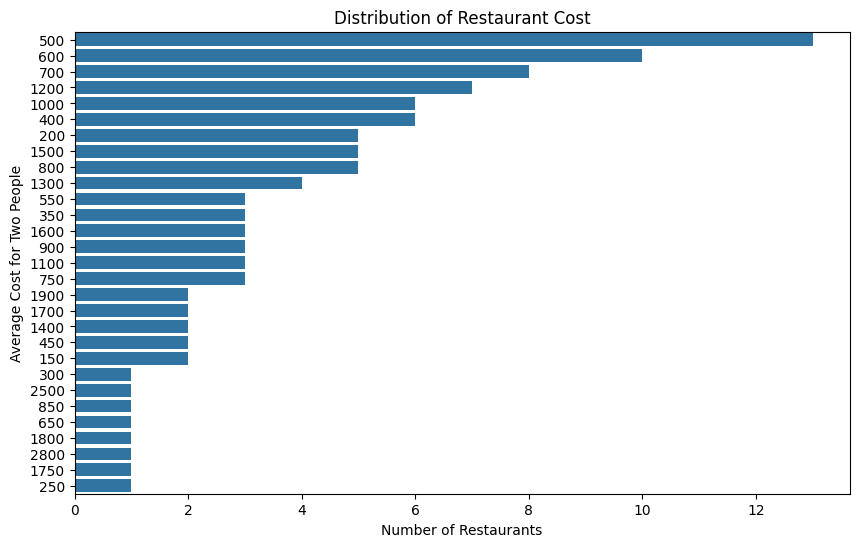

In [170]:
# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a count plot to show the distribution of restaurant cost
sns.countplot(
    y='Cost',
    data=restaurant_df,
    order=restaurant_df['Cost'].value_counts().index
)

# Add a title to the chart
plt.title('Distribution of Restaurant Cost')

# Label the x-axis
plt.xlabel('Number of Restaurants')

# Label the y-axis
plt.ylabel('Average Cost for Two People')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Count Plot** because it shows how many restaurants belong to each cost category. It helps understand which price ranges have the highest and lowest number of restaurants.

#### Why Count Plot and not Bar Plot?

- A **Count Plot** is used because it automatically counts how many restaurants belong to each **Cost** category. Since the goal is to show the **frequency (number of restaurants)** in each price range, a count plot is the most appropriate choice.

- A **Bar Plot** is generally used when the data is already summarized, such as **average cost, average rating, total reviews, or total number of restaurants**. In this chart, no calculations were performed beforehand, so a bar plot is not required.

Since Cost column is a categorical variable with repeated values (₹500, ₹600, ₹800, etc.), Count Plot is the correct chart. It automatically counts how many restaurants belong to each cost category.


#### 2. What is/are the insight(s) found from the chart?

- The **₹500** cost category has the highest number of restaurants.
- Restaurants with an average cost of **₹600, ₹700, ₹800, and ₹1200** are also common.
- Most restaurants have an average cost between **₹500 and ₹1200**, showing that they are moderately priced.
- Very few restaurants have an average cost below **₹300** or above **₹1800**.
- This indicates that the dataset mainly contains **budget-friendly and mid-range restaurants**, while expensive restaurants are fewer in number.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners can keep their prices between **₹500 and ₹1200** to attract more customers.  
  **Example:** If a restaurant reduces its average cost from **₹1800** to around **₹1000**, it may attract more customers because this price range is more popular.

- Zomato can recommend restaurants based on customers' budgets.  
  **Example:** If a customer wants to spend around **₹800**, Zomato can recommend restaurants with an average cost close to **₹800**.

- Restaurant owners can compare their prices with similar restaurants and set competitive prices.  
  **Example:** If nearby restaurants charge around **₹700**, a restaurant owner can keep a similar price to attract more customers.

##### Negative Business Impact

- Restaurants with an average cost above **₹1800** may receive fewer customers because they are more expensive.  
  **Example:** A restaurant with an average cost of **₹2500** may attract fewer customers than a restaurant charging **₹800**, as many customers prefer affordable restaurants.

- There are very few low-cost restaurants, giving customers fewer budget-friendly options.  
  **Example:** A customer looking for restaurants with an average cost of **₹300** may have fewer choices because only a small number of restaurants are available in that price range.

## Chart 2 (Bar chart) : Top 10 Most Popular Cuisines

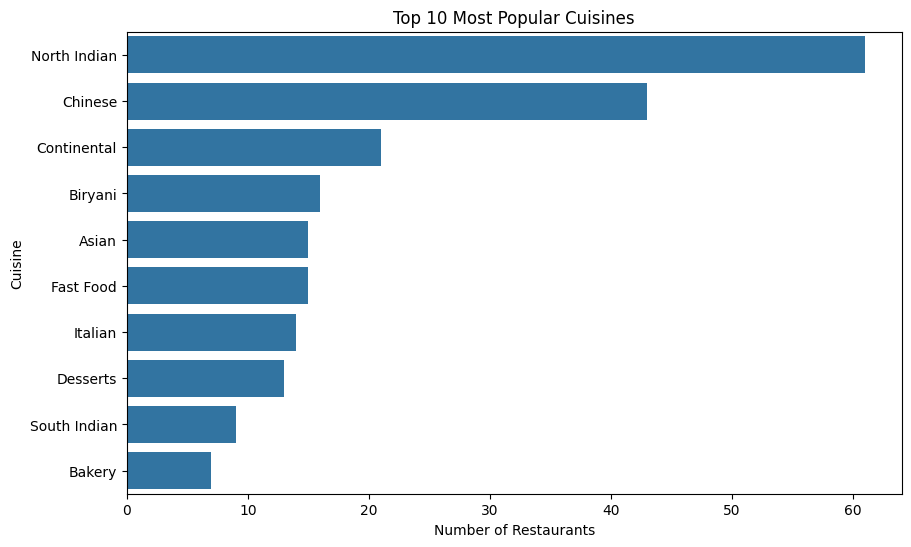

In [171]:
# Split multiple cuisines into individual cuisines
cuisines = restaurant_df['Cuisines'].str.split(', ').explode()

# Count the frequency of each cuisine and select the top 10
top_10_cuisines = cuisines.value_counts().head(10)

# Create a figure with the specified size
plt.figure(figsize=(10,6))

# Create a bar plot to display the top 10 most popular cuisines
sns.barplot(x=top_10_cuisines.values, y=top_10_cuisines.index)

# Add a title to the chart
plt.title('Top 10 Most Popular Cuisines')

# Label the x-axis
plt.xlabel('Number of Restaurants')

# Label the y-axis
plt.ylabel('Cuisine')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

A **Bar Plot** was chosen because it is the best chart for comparing the number of restaurants serving different cuisines. It clearly shows the top 10 most popular cuisines and makes comparison easy.

#### 2. What is/are the insight(s) found from the chart?

- **North Indian** cuisine is the most popular, as it is served by the highest number of restaurants.
- **Chinese** cuisine is the second most common cuisine.
- **Continental** cuisine is also popular but is served by fewer restaurants than North Indian and Chinese cuisines.
- **Biryani, Asian, Fast Food, Italian, Desserts, South Indian, and Bakery** are also available but in smaller numbers.
- Overall, customers have a wide variety of cuisine options, with North Indian and Chinese being the most common choices.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners can include popular cuisines like **North Indian** and **Chinese** to attract more customers.  
  **Example:** If a new restaurant adds **North Indian** and **Chinese** dishes to its menu, it may attract more customers because these cuisines are popular.

- Zomato can recommend restaurants based on customers' favourite cuisines.  
  **Example:** If a customer searches for **Chinese** food, Zomato can recommend restaurants that serve Chinese cuisine.

- Restaurant owners can understand customer food preferences and plan their menus accordingly.  
  **Example:** If many customers prefer **North Indian** cuisine, a restaurant can add more North Indian dishes to its menu.

##### Negative Business Impact

- Restaurants serving less popular cuisines, such as **Bakery** or **South Indian**, may attract fewer customers.  
  **Example:** A restaurant that serves only **Bakery** items may receive fewer customers because fewer restaurants in the dataset offer this cuisine.

- Many restaurants serve **North Indian** and **Chinese** food, so the competition is high.  
  **Example:** If a new restaurant also serves **North Indian** cuisine, it has to compete with many existing restaurants that already offer the same cuisine.

## Chart 3 (Bar chart) : Top Restaurant Collections

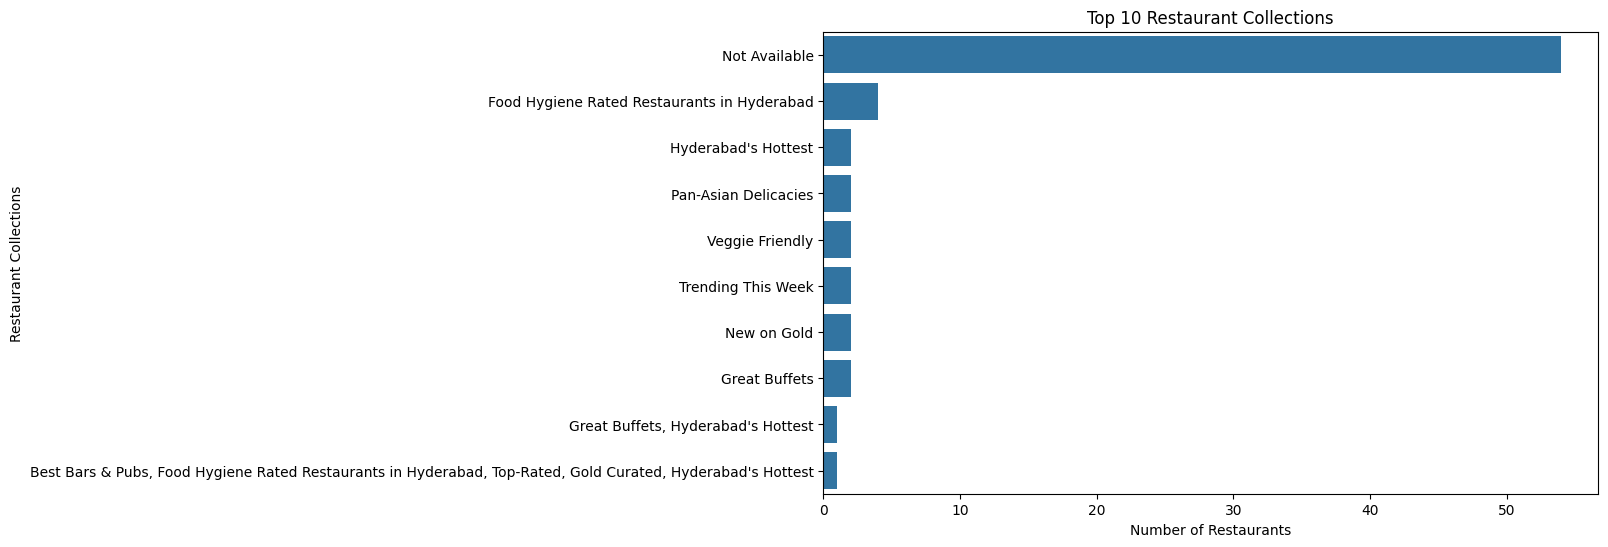

In [172]:
# Count the frequency of each restaurant collection
top_collections = restaurant_df['Collections'].value_counts().head(10)

# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a bar plot to display the top 10 restaurant collections
sns.barplot(x=top_collections.values, y=top_collections.index)

# Add a title to the chart
plt.title('Top 10 Restaurant Collections')

# Label the x-axis
plt.xlabel('Number of Restaurants')

# Label the y-axis
plt.ylabel('Restaurant Collections')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

A **Bar Plot** was chosen because it makes it easy to compare different restaurant collections. It clearly shows which collections have the highest and lowest number of restaurants.

#### 2. What is/are the insight(s) found from the chart?

- Many restaurants do not have collection information, so they are shown as **"Not Available"**.
- **Food Hygiene Rated Restaurants in Hyderabad** is the most common restaurant collection.
- **Hyderabad's Hottest**, **Pan-Asian Delicacies**, **Veggie Friendly**, and **Trending This Week** are also popular collections.
- Some collections have only a few restaurants.
- The restaurants belong to different collections, giving customers many options to choose from.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Popular restaurant collections can attract more customers.  
  **Example:** If Zomato highlights **"Food Hygiene Rated Restaurants in Hyderabad"** on its home page, more customers may visit these restaurants because they trust restaurants with good hygiene.

- Zomato can recommend restaurants based on popular collections.  
  **Example:** If a customer searches for **"Hyderabad's Hottest"**, Zomato can recommend restaurants from that collection, making it easier for the customer to choose.

- Restaurant owners can improve their restaurants to be included in popular collections.  
  **Example:** A restaurant owner can improve food quality, cleanliness, and customer service to become part of **"Food Hygiene Rated Restaurants in Hyderabad"**, which can help attract more customers.

##### Negative Business Impact

- Many restaurants do not have collection information.  
  **Example:** If a restaurant has **"Not Available"** in the **Collections** column, customers will not know whether it belongs to any special collection.

- Missing collection information may reduce restaurant visibility.  
  **Example:** If a customer filters restaurants by **"Food Hygiene Rated Restaurants"**, restaurants with **"Not Available"** will not appear in the results, so fewer customers may find and visit them.

## Chart 4 (Count chart): Restaurant Timings Distribution

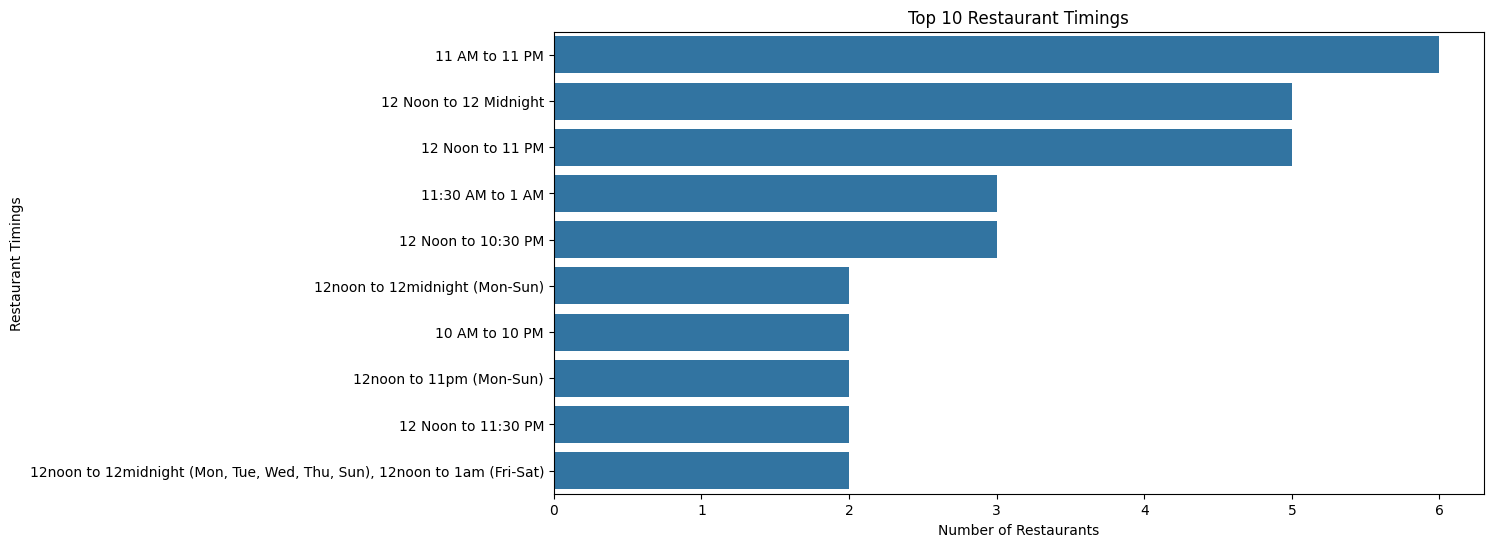

In [173]:
# Count the frequency of each restaurant timing
top_timings = restaurant_df['Timings'].value_counts().head(10)

# Create a new figure with the specified size
plt.figure(figsize=(12,6))

# Create a count of the top 10 restaurant timings using a bar plot
sns.barplot(x=top_timings.values, y=top_timings.index)

# Add a title to the chart
plt.title('Top 10 Restaurant Timings')

# Label the x-axis
plt.xlabel('Number of Restaurants')

# Label the y-axis
plt.ylabel('Restaurant Timings')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

A **Bar Plot** was chosen because it makes it easy to compare the number of restaurants with different opening and closing timings. It clearly shows the most common restaurant timings.

#### 2. What is/are the insight(s) found from the chart?

- Around **6 restaurants** operate from **11 AM to 11 PM**, making it the most common restaurant timing.
- Around **5 restaurants** operate from **12 Noon to 12 Midnight** and **12 Noon to 11 PM**.
- Around **3 restaurants** operate from **11:30 AM to 1 AM** and **12 Noon to 10:30 PM**.
- Around **2 restaurants** follow timings such as **12 Noon to 12 Midnight (Mon–Sun)**, **10 AM to 10 PM**, **12 Noon to 11:30 PM**, and similar schedules.
- Overall, most restaurants remain open from **11 AM or 12 Noon** until **11 PM or 12 Midnight**, providing customers with enough time for both lunch and dinner.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurants with popular timings can attract more customers.  
  **Example:** A restaurant open from **11 AM to 11 PM** can serve customers during both lunch and dinner, increasing sales.

- Zomato can recommend restaurants that are open when customers want to order food.  
  **Example:** If a customer wants food at **10 PM**, Zomato can show restaurants that are still open.

- New restaurant owners can choose popular opening and closing times.  
  **Example:** A new restaurant can operate from **11 AM to 11 PM**, as this is the most common timing among restaurants.

##### Negative Business Impact

- Restaurants with shorter opening hours may get fewer customers.  
  **Example:** A restaurant that closes at **8 PM** may miss customers who want dinner later in the evening.

- Restaurants open for very long hours may have higher operating costs.  
  **Example:** A restaurant open until **1 AM** may spend more on staff salaries, electricity, and other expenses.

## Chart 5 (Histogram Chart) : Customer Rating Distribution

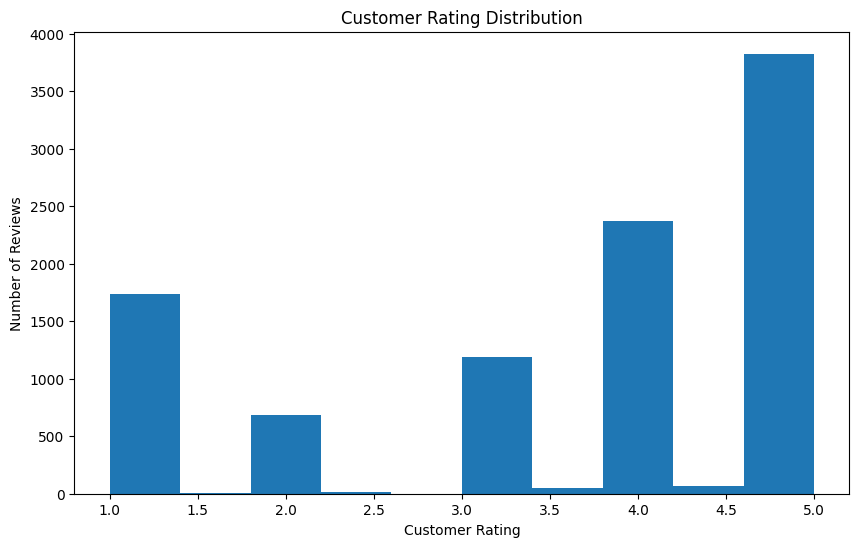

In [174]:
# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a histogram to show the distribution of customer ratings
plt.hist(review_df['Rating'], bins=10)

# Add a title to the chart
plt.title('Customer Rating Distribution')

# Label the x-axis
plt.xlabel('Customer Rating')

# Label the y-axis
plt.ylabel('Number of Reviews')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Histogram** because it shows how customer ratings are distributed. It helps identify which ratings are given most often and whether most reviews are high, low, or evenly distributed.

#### 2. What is/are the insight(s) found from the chart?

- Around **3,800 reviews** have a **5-star rating**, making it the most common rating.
- Around **2,400 reviews** have a **4-star rating**, showing that many customers are satisfied.
- Around **1,200 reviews** have a **3-star rating**, indicating average customer satisfaction.
- Around **1,700 reviews** have a **1-star rating**, while around **700 reviews** have a **2-star rating**, showing that some customers were not satisfied.
- Overall, most reviews are **4 and 5 stars**, indicating that customers are generally happy with the restaurants.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Most restaurants receive **4 and 5-star ratings**, showing good customer satisfaction.  
  **Example:** A restaurant with a **5-star rating** is more likely to attract new customers.

- Zomato can recommend highly rated restaurants to customers.  
  **Example:** If a customer searches for the best restaurants, Zomato can show restaurants with **4 or 5-star ratings**.

- Restaurant owners can maintain good food and service to keep receiving high ratings.  
  **Example:** A restaurant with **4.5 or 5-star ratings** can continue providing quality food and service to keep customers happy.

##### Negative Business Impact

- Restaurants with **1 or 2-star ratings** may lose customers because of poor reviews.  
  **Example:** A customer may avoid visiting a restaurant with a **1-star rating** after reading negative reviews.

- Low-rated restaurants need to improve their food quality and customer service.  
  **Example:** A restaurant with many **2-star ratings** should improve its service to receive better ratings in the future.

## Chart 6 (Histogram chart) : Distribution of Pictures Uploaded

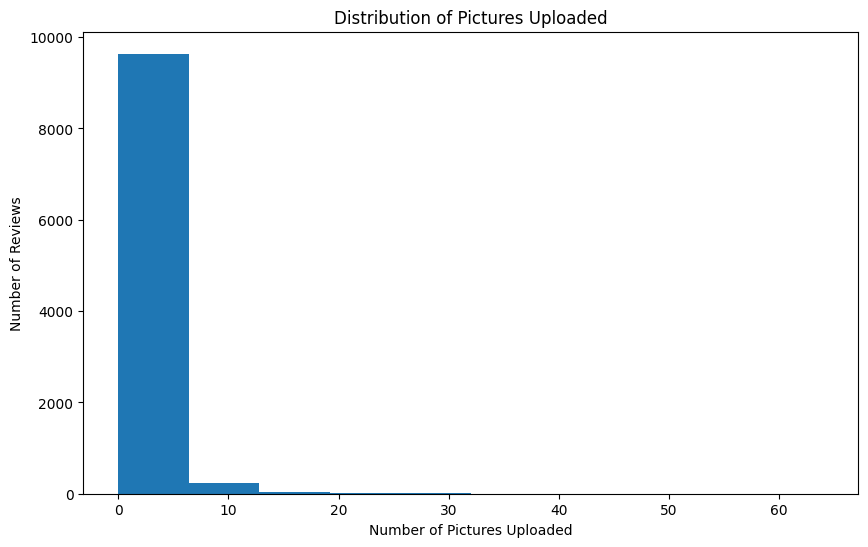

In [175]:
# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a histogram to show the distribution of pictures uploaded
plt.hist(review_df['Pictures'], bins=10)

# Add a title to the chart
plt.title('Distribution of Pictures Uploaded')

# Label the x-axis
plt.xlabel('Number of Pictures Uploaded')

# Label the y-axis
plt.ylabel('Number of Reviews')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Histogram** because it shows how the number of pictures uploaded is distributed. It helps identify how many pictures customers usually upload with their reviews.

#### 2. What is/are the insight(s) found from the chart?

- Around **9,600–9,700 reviews** have **0 pictures**, showing that most customers do not upload pictures with their reviews.
- Around **200–300 reviews** have **1 to 5 pictures**, indicating that only a few customers upload a small number of pictures.
- Fewer than **100 reviews** have **6 to 10 pictures**, showing that uploading many pictures is uncommon.
- Only a **very small number of reviews** have **more than 10 pictures**, with the maximum being **64 pictures**.
- Overall, most customers prefer to write reviews without uploading pictures, while only a few customers share photos with their reviews.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurants can encourage customers to upload pictures with their reviews.
  **Example:** A restaurant can offer a small discount or reward points to customers who upload food pictures.

- Zomato can highlight reviews with pictures because they help customers make better decisions.
  **Example:** A customer is more likely to trust a review that includes photos of the food.

- Restaurant owners can use customer-uploaded pictures to showcase their dishes.
  **Example:** Good-quality customer photos can attract more people to visit the restaurant.

##### Negative Business Impact

- Most reviews do not contain pictures, so customers may not get a visual idea of the food.
  **Example:** A restaurant with only text reviews may receive less attention than one with attractive food photos.

- Restaurants with very few photo reviews may have lower customer engagement.
  **Example:** If a restaurant has no customer-uploaded pictures, some customers may choose another restaurant with more visual reviews.

# Bivariate Analysis

### Objective of Bivariate Analysis

- To analyze the relationship between two variables.
- To understand how one variable affects another.
- To identify patterns, trends, and correlations between variables.
- To compare different variables and their impact on each other.
- To gain better insights for decision-making and business analysis.

## Chart 7 (Scatter Plot) : Cost vs Customer Rating

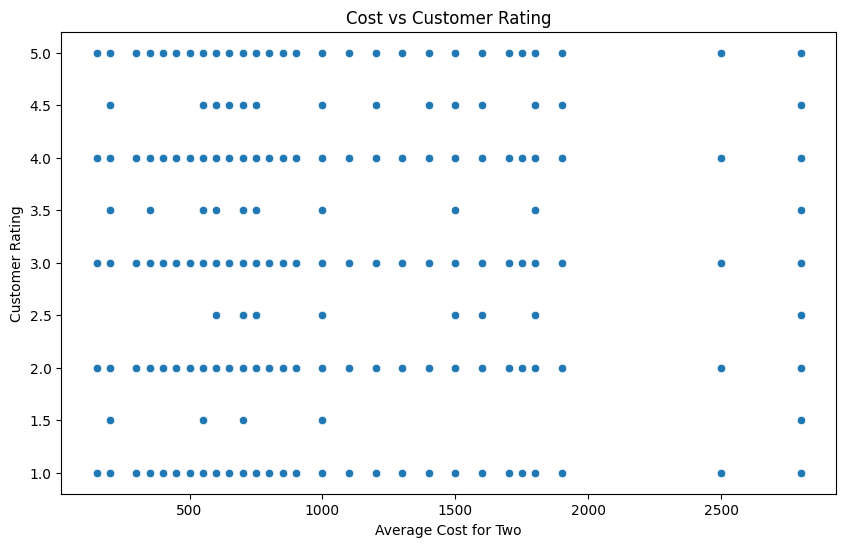

In [176]:
# Merge restaurant and review datasets using the Restaurant Name
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a scatter plot between Cost and Rating
sns.scatterplot(
    x='Cost',
    y='Rating',
    data=merged_df
)

# Add a title to the chart
plt.title('Cost vs Customer Rating')

# Label the x-axis
plt.xlabel('Average Cost for Two')

# Label the y-axis
plt.ylabel('Customer Rating')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Scatter Plot** because it shows the relationship between **restaurant cost** and **customer rating**. It helps us understand whether expensive restaurants receive higher ratings.

#### 2. What is/are the insight(s) found from the chart?

- Restaurants with costs between **₹200 and ₹1900** have ratings ranging from **1 to 5 stars**.
- Both **low-cost** and **high-cost** restaurants receive **high ratings (4 and 5 stars)**.
- Some expensive restaurants (around **₹2500–₹2800**) also have **low ratings**, showing that a higher price does not always mean better customer satisfaction.
- Most restaurants, regardless of their cost, have ratings spread across different values.
- Overall, there is **no strong relationship** between restaurant cost and customer rating.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners should focus on **food quality and service**, not just price.
  **Example:** A restaurant charging **₹700** can still receive **5-star ratings** by providing good food and service.

- Zomato can recommend restaurants based on **customer ratings** instead of only price.
  **Example:** A customer looking for highly rated restaurants can find both budget-friendly and expensive options.

- Budget-friendly restaurants can compete with premium restaurants by maintaining good customer satisfaction.
  **Example:** A **₹500** restaurant with a **5-star rating** can attract as many customers as a **₹2500** restaurant.

##### Negative Business Impact

- Charging a higher price does not guarantee better ratings.
  **Example:** Some restaurants costing **₹2500–₹2800** have ratings below **3 stars**, which may discourage customers.

- Restaurants with poor service or food quality may receive low ratings even if they are expensive.
  **Example:** A customer may avoid an expensive restaurant with a **2-star rating** and choose a lower-cost restaurant with a **5-star rating**.

## Chart 8 (Box Plot): Average Cost by Collection

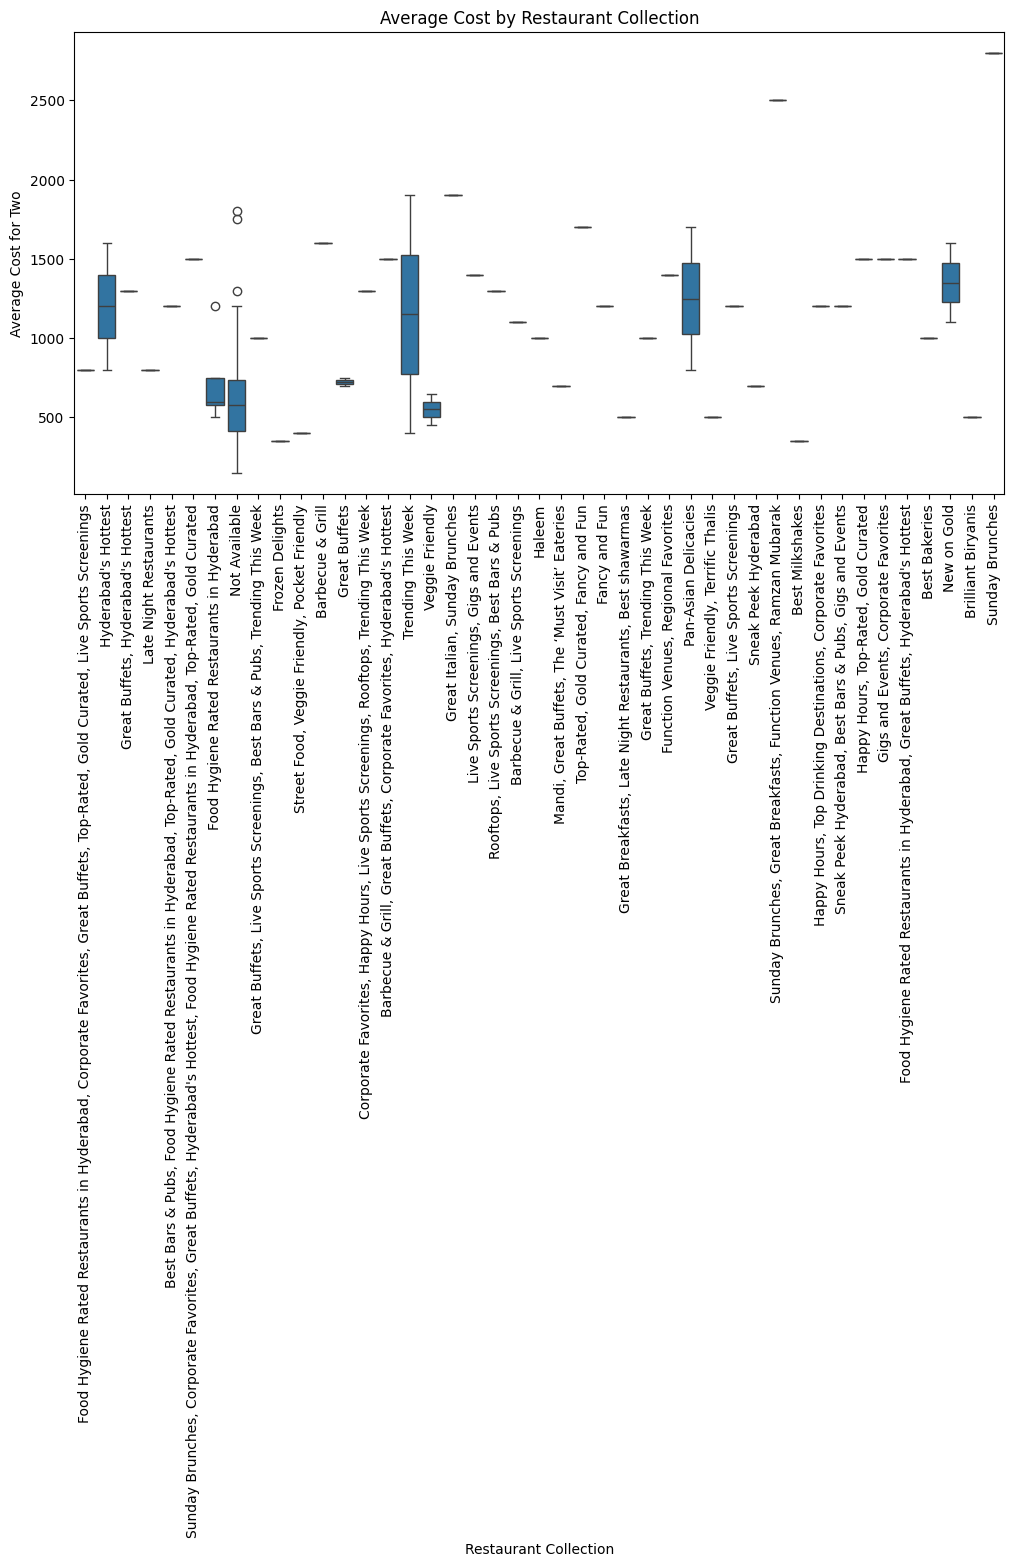

In [177]:
# Create a new figure with the specified size
plt.figure(figsize=(12,6))

# Create a box plot to compare restaurant costs across collections
sns.boxplot(
    x='Collections',
    y='Cost',
    data=restaurant_df
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add a title to the chart
plt.title('Average Cost by Restaurant Collection')

# Label the x-axis
plt.xlabel('Restaurant Collection')

# Label the y-axis
plt.ylabel('Average Cost for Two')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Box Plot** because it makes it easy to compare restaurant costs in different collections. It also shows the lowest, highest, and middle cost of restaurants in each collection.
```

#### 2. What is/are the insight(s) found from the chart?

- Restaurant prices are **different** in different collections.
- Some collections have **high-cost restaurants (around ₹2500–₹2800)**, while others have lower-cost restaurants.
- Most restaurants have an average cost between **₹500 and ₹1500**.
- In some collections, restaurant prices are **very different**, while in others they are almost the same.
- A few restaurants are **much more expensive** than other restaurants in the same collection.

###3 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners can compare their prices with similar restaurants.  
  **Example:** If most restaurants in a collection charge **₹1200**, a new restaurant can keep a similar price.

- Zomato can suggest restaurants based on a customer's budget.  
  **Example:** If a customer wants to spend **₹800**, Zomato can recommend restaurants in that price range.

- Restaurant owners can decide the right price for their food.  
  **Example:** A premium restaurant can charge a higher price if it offers better food and service.

##### Negative Business Impact

- Restaurants with very high prices may get fewer customers.  
  **Example:** A restaurant charging **₹2800** may get fewer customers because many people prefer lower-priced restaurants.

- Restaurants in the same collection with very different prices may confuse customers.  
  **Example:** One restaurant charges **₹600** and another charges **₹1900**, so customers may not know which one fits their budget.

## Chart 9 (Bar Plot) : Top 10 Cuisines by Average Cost

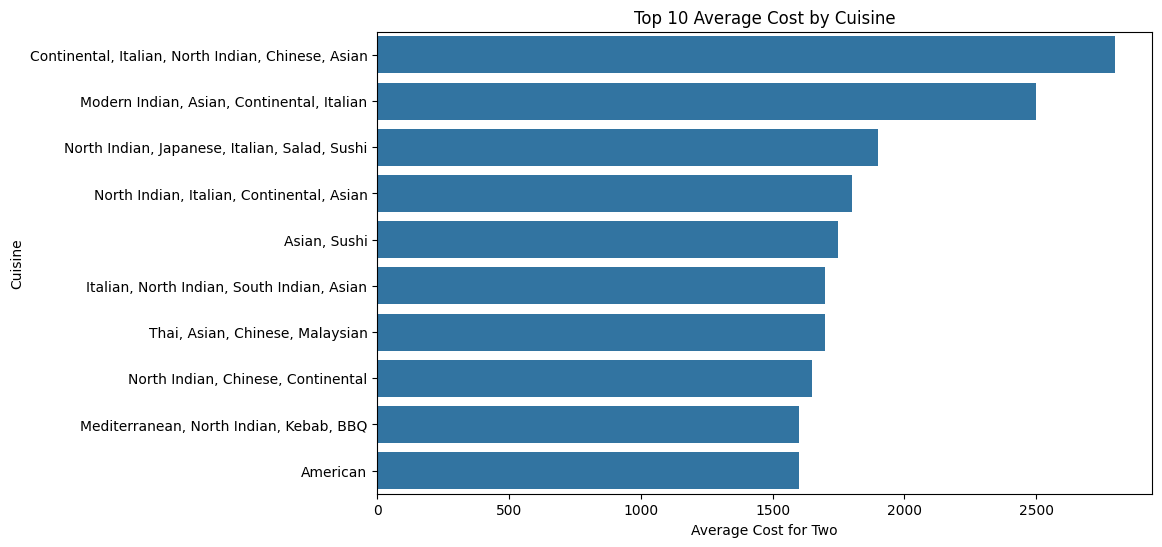

In [178]:
# Calculate the average cost for each cuisine
avg_cost = restaurant_df.groupby('Cuisines')['Cost'].mean().sort_values(ascending=False).head(10)

# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a bar plot to compare the average cost of different cuisines
sns.barplot(
    x=avg_cost.values,
    y=avg_cost.index
)

# Add a title to the chart
plt.title('Top 10 Average Cost by Cuisine')

# Label the x-axis
plt.xlabel('Average Cost for Two')

# Label the y-axis
plt.ylabel('Cuisine')

# Display the chart
plt.show()


#### 1. Why did you pick the specific chart?

I chose a **Bar Plot** because it makes it easy to compare the average cost of different cuisines and identify which cuisines are more expensive or more affordable.

#### 2. What is/are the insight(s) found from the chart?

- The cuisine combination **Continental, Italian, North Indian, Chinese, Asian** has the **highest average cost** of around **₹2800**.
- **Modern Indian, Asian, Continental, Italian** has the second highest average cost of around **₹2500**.
- Most of the top 10 cuisines have an average cost between **₹1600 and ₹1900**.
- **American** cuisine has the lowest average cost among the top 10, at around **₹1600**.
- Overall, cuisines with multiple international food options have higher average prices.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners can decide prices based on the cuisine they serve.  
  **Example:** A restaurant serving **Continental and Italian** food can charge a higher price because similar restaurants also have higher prices.

- Zomato can recommend restaurants based on customers' budgets.  
  **Example:** Customers looking for premium dining can be shown cuisines with higher average costs.

- Restaurant owners can understand which cuisines are usually premium.  
  **Example:** Restaurants serving international cuisines can improve their menu and pricing to match customer expectations.

##### Negative Business Impact

- High-priced cuisines may attract fewer customers because not everyone can afford them.  
  **Example:** A restaurant with an average cost of **₹2800** may receive fewer customers than a restaurant costing **₹1600**.

- Expensive cuisine combinations face more competition from similar premium restaurants.  
  **Example:** A new premium restaurant must provide better food and service to attract customers from other high-priced restaurants.

## Chart 10 (Bar Plot): Top 10 Restaurants by Average Rating

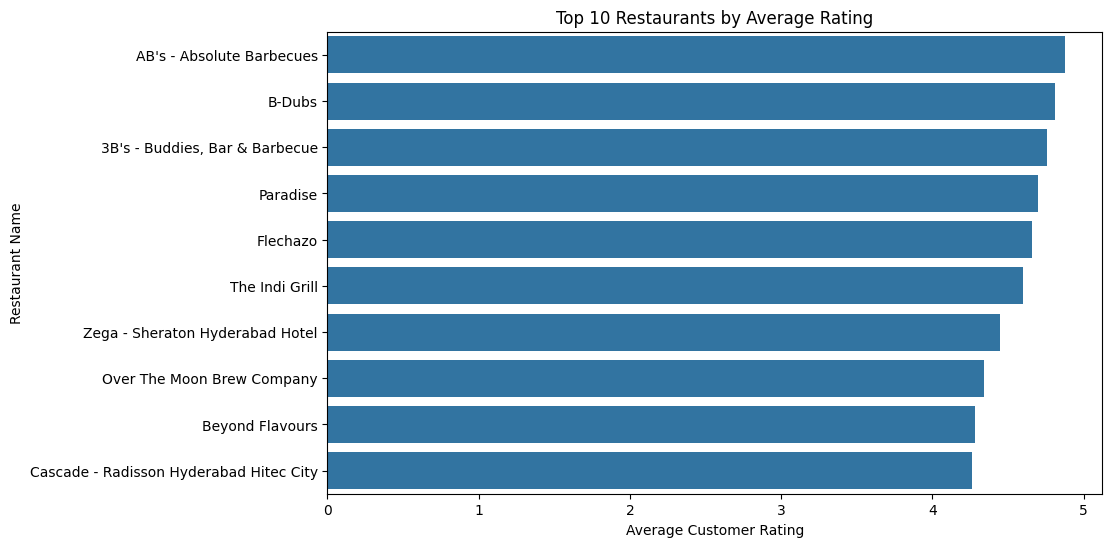

In [179]:
# Calculate the average rating for each restaurant
avg_rating = review_df.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10)

# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a bar plot to compare average ratings of restaurants
sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)

# Add a title to the chart
plt.title('Top 10 Restaurants by Average Rating')

# Label the x-axis
plt.xlabel('Average Customer Rating')

# Label the y-axis
plt.ylabel('Restaurant Name')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Bar Plot** because it makes it easy to compare the average ratings of different restaurants. It clearly shows which restaurants have the highest customer ratings.

#### 2. What is/are the insight(s) found from the chart?

- **AB's - Absolute Barbecues** has the highest average customer rating of around **4.9**.
- **B-Dubs** and **3B's - Buddies, Bar & Barbecue** also have very high average ratings of around **4.8**.
- **Paradise**, **Flechazo**, and **The Indi Grill** have average ratings between **4.6 and 4.7**.
- All the top 10 restaurants have average ratings above **4.2**, showing high customer satisfaction.
- Overall, these restaurants are highly rated and are popular among customers.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Highly rated restaurants can attract more customers.
  **Example:** Customers are more likely to visit **AB's - Absolute Barbecues** because it has an average rating of **4.9**.

- Zomato can recommend these top-rated restaurants to users.
  **Example:** If a customer searches for the best restaurants, Zomato can suggest **B-Dubs** or **Paradise**.

- Restaurant owners can learn from highly rated restaurants and improve their food and service.
  **Example:** A new restaurant can study **Flechazo** to understand what customers like.

##### Negative Business Impact

- Restaurants with lower ratings may receive fewer customers.
  **Example:** Customers may choose **AB's - Absolute Barbecues** instead of a restaurant with a lower rating.

- New or lower-rated restaurants may find it difficult to compete with highly rated restaurants.
  **Example:** A new restaurant may need better food, service, or offers to compete with restaurants having **4.8–4.9** ratings.

## Chart 11 (Bar Plot): Top 10 Restaurants by Number of Reviews

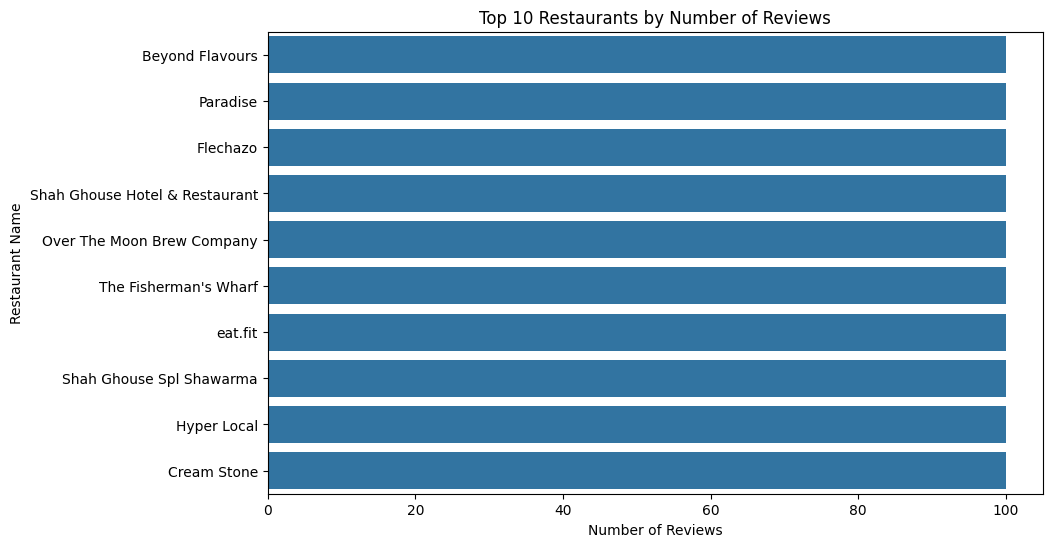

In [180]:
# Count the number of reviews for each restaurant
review_count = review_df['Restaurant'].value_counts().head(10)

# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a bar plot to show the top 10 restaurants with the highest number of reviews
sns.barplot(
    x=review_count.values,
    y=review_count.index
)

# Add a title to the chart
plt.title('Top 10 Restaurants by Number of Reviews')

# Label the x-axis
plt.xlabel('Number of Reviews')

# Label the y-axis
plt.ylabel('Restaurant Name')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Bar Plot** because it makes it easy to compare the number of reviews received by different restaurants. It clearly shows which restaurants have the highest customer engagement.

#### 2. What is/are the insight(s) found from the chart?

- **Beyond Flavours**, **Paradise**, **Flechazo**, **Shah Ghouse Hotel & Restaurant**, and the other top restaurants have **around 100 reviews** each.
- All the top 10 restaurants have **almost the same number of reviews**, showing that they are equally popular among customers.
- Restaurants like **Cream Stone**, **Hyper Local**, **eat.fit**, and **The Fisherman's Wharf** also have around **100 customer reviews**.
- The high number of reviews shows that these restaurants have good customer engagement.
- Overall, these restaurants are popular because many customers have shared their experiences.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurants with more reviews can attract more customers.  
  **Example:** A customer is more likely to visit **Paradise** because it has around **100 reviews**.

- Zomato can recommend restaurants that have many customer reviews.  
  **Example:** Customers looking for trusted restaurants can be shown **Beyond Flavours** or **Cream Stone**.

- Restaurant owners can encourage customers to write reviews to increase their restaurant's visibility.  
  **Example:** A restaurant can ask customers to leave a review after their meal.

##### Negative Business Impact

- Restaurants with fewer reviews may receive less attention from customers.  
  **Example:** A new restaurant with only **10–20 reviews** may be ignored compared to restaurants with **100 reviews**.

- Customers may trust restaurants with many reviews more than restaurants with very few reviews.  
  **Example:** A customer may choose **Flechazo** instead of a new restaurant because it has many customer reviews.

## Chart 12 (Scatter Plot): Cost vs Pictures Uploaded

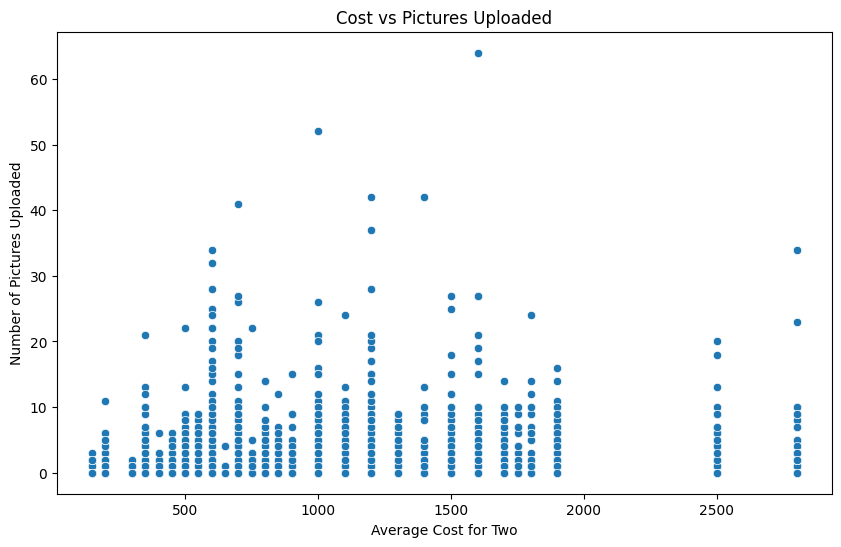

In [181]:
# Merge the restaurant and review datasets using the restaurant name
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Create a new figure with the specified size
plt.figure(figsize=(10,6))

# Create a scatter plot between Cost and Pictures
sns.scatterplot(
    x='Cost',
    y='Pictures',
    data=merged_df
)

# Add a title to the chart
plt.title('Cost vs Pictures Uploaded')

# Label the x-axis
plt.xlabel('Average Cost for Two')

# Label the y-axis
plt.ylabel('Number of Pictures Uploaded')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Scatter Plot** because it shows the relationship between **restaurant cost** and the **number of pictures uploaded** by customers. It helps us understand whether expensive restaurants receive more customer pictures.

#### 2. What is/are the insight(s) found from the chart?

- Restaurants with costs between **₹500 and ₹1900** have pictures uploaded ranging from **0 to about 64**.
- The **highest number of pictures uploaded is around 64**, for a restaurant costing about **₹1600**.
- Some expensive restaurants (around **₹2500–₹2800**) have only a **few pictures (0–34)**.
- Many restaurants, regardless of their cost, have **less than 10 pictures** uploaded.
- Overall, there is **no strong relationship** between restaurant cost and the number of pictures uploaded.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners can encourage customers to upload more pictures.
  **Example:** A restaurant can offer reward points to customers who upload food photos.

- Zomato can show restaurants with more customer pictures.
  **Example:** Customers can see real food photos before deciding where to eat.

- Good food and presentation can encourage customers to share pictures.
  **Example:** A restaurant with attractive dishes may receive more photo uploads.

##### Negative Business Impact

- Expensive restaurants do not always receive more customer pictures.
  **Example:** A restaurant costing **₹2800** may have only a few pictures uploaded.

- Restaurants with very few customer pictures may attract fewer customers.
  **Example:** Customers may choose a restaurant with many food photos instead of one with no pictures.

# Multivariate Analysis

## Objective of Multivariate Analysis

- To analyze the relationship between three or more variables.
- To understand how multiple variables affect each other.
- To identify patterns and trends among different variables.
- To compare the combined effect of multiple variables.
- To gain deeper insights for better business decisions.

## Chart 13 (Bubble Plot): Cuisine vs Cost vs Customer Rating


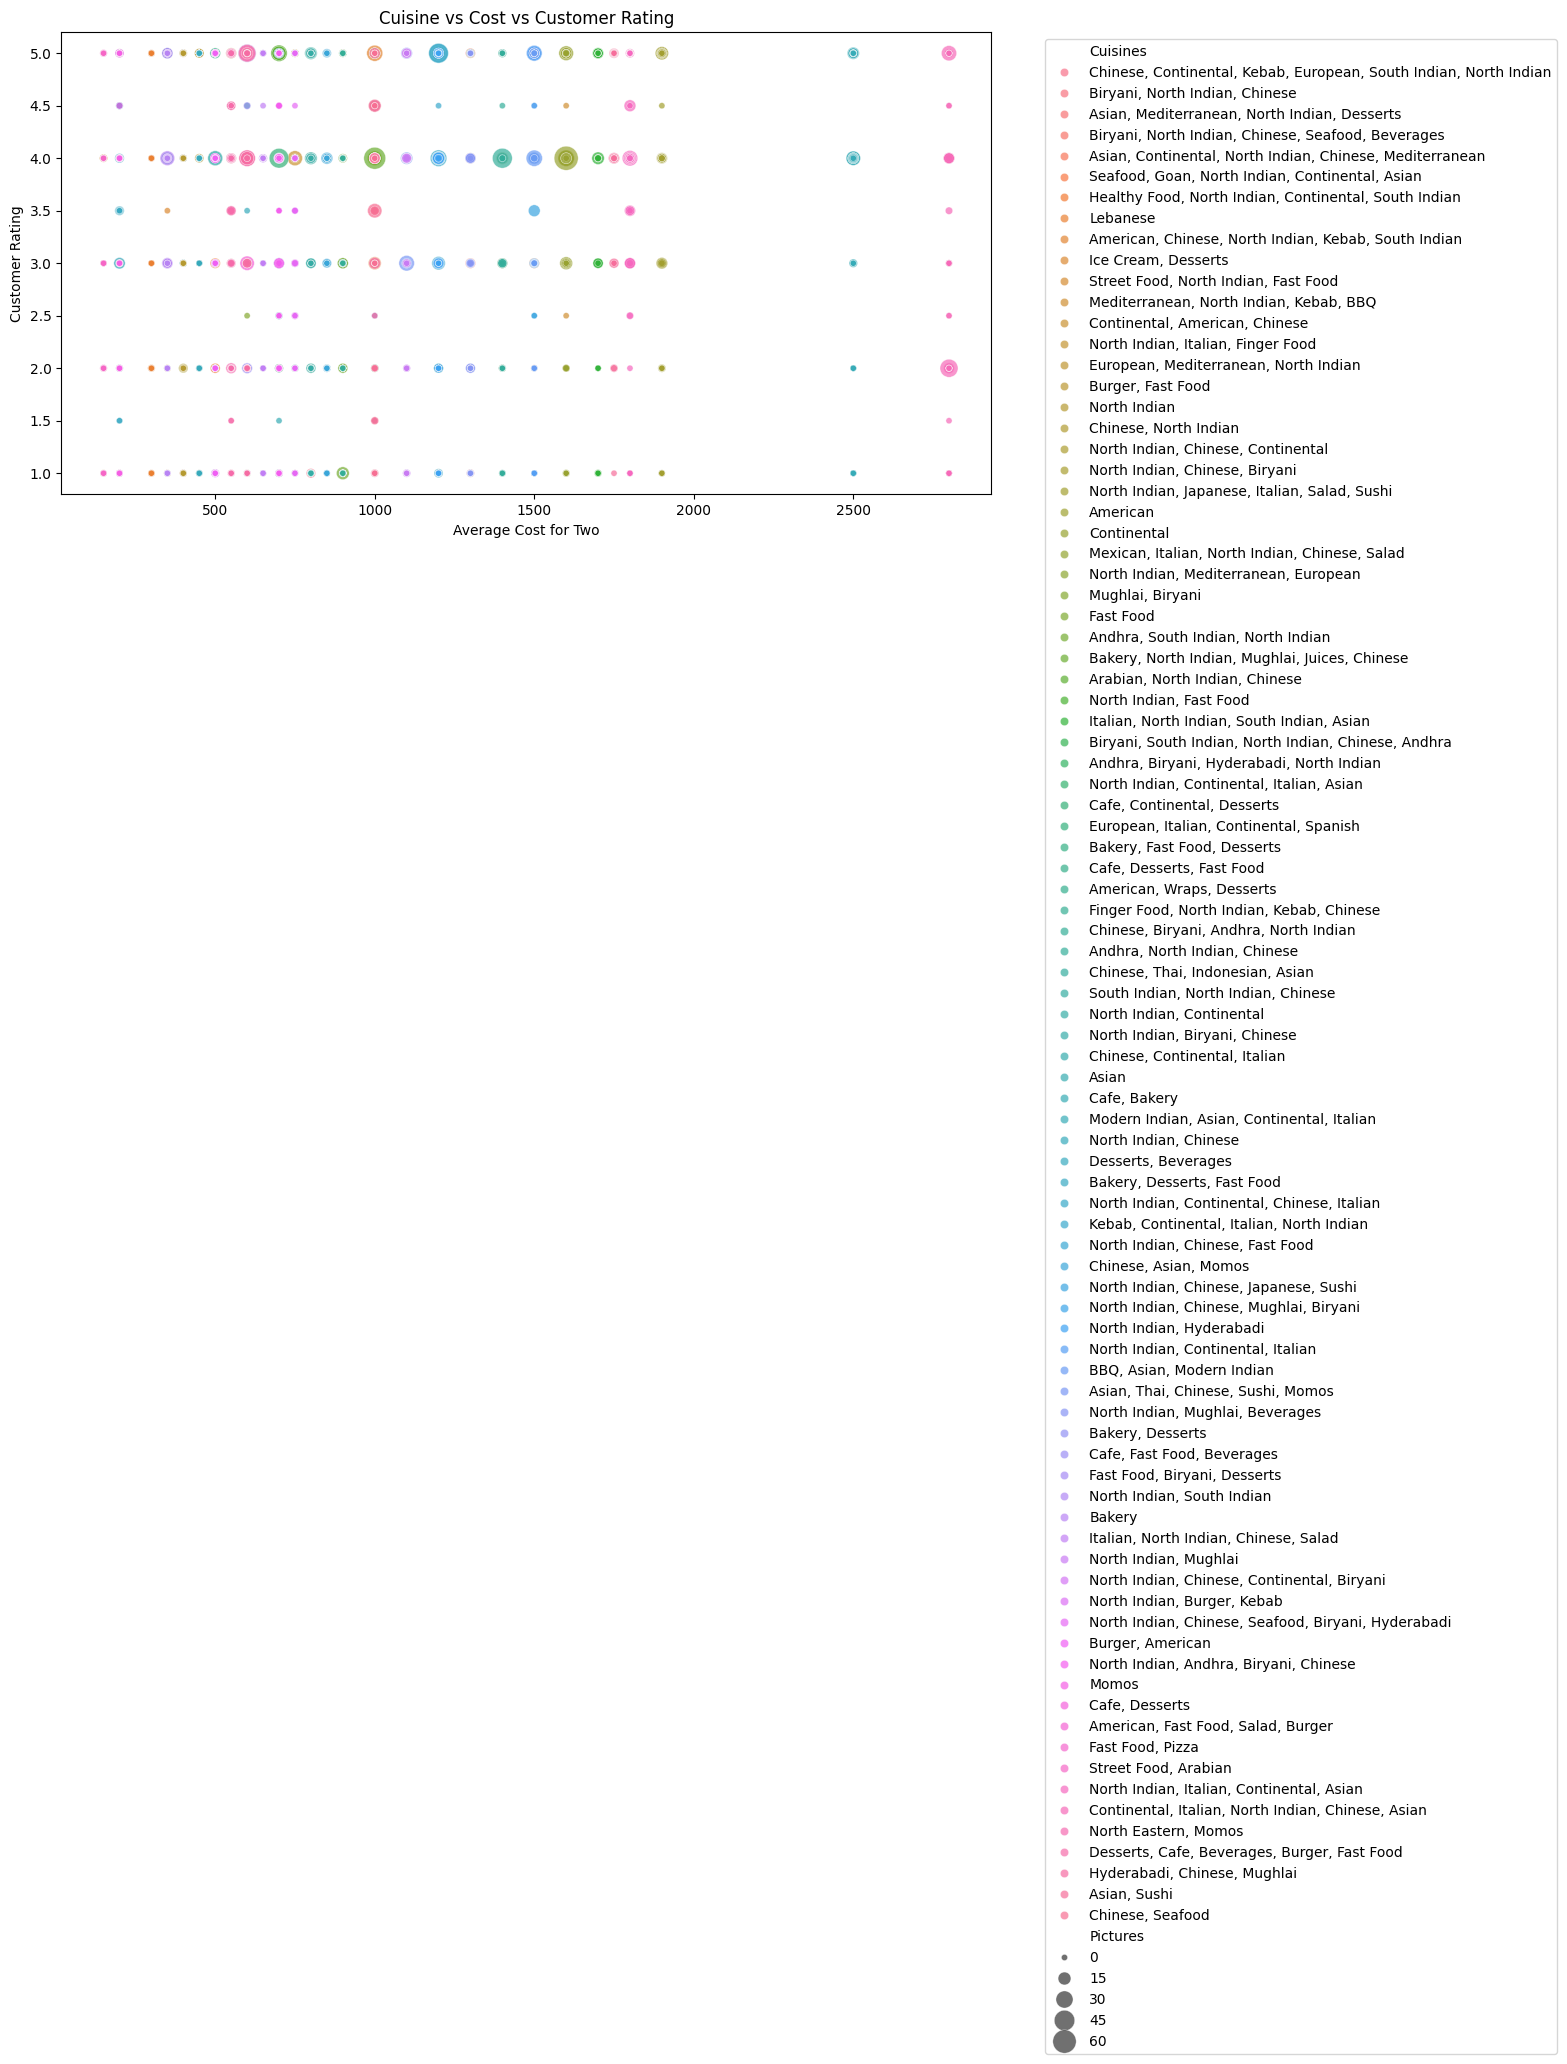

In [182]:
# Merge the restaurant and review datasets using the restaurant name
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Create a new figure with the specified size
plt.figure(figsize=(12,6))

# Create a bubble plot
sns.scatterplot(
    data=merged_df,
    x='Cost',
    y='Rating',
    size='Pictures',
    hue='Cuisines',
    sizes=(20,300),
    alpha=0.7
)

# Add a title to the chart
plt.title('Cuisine vs Cost vs Customer Rating')

# Label the x-axis
plt.xlabel('Average Cost for Two')

# Label the y-axis
plt.ylabel('Customer Rating')

# Display the legend outside the plot
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Bubble Plot** because it helps compare **multiple variables** in a single chart. It shows the relationship between **cuisine, restaurant cost, customer rating, and the number of pictures uploaded**, making it easier to identify patterns.

#### 2. What is/are the insight(s) found from the chart?

- Different cuisines have different restaurant prices and customer ratings.
- Most restaurants have an average cost between **₹500 and ₹1800**.
- Most restaurants have **4-star and 5-star ratings**.
- Restaurants with more customer pictures are mostly rated **4 or 5 stars**.
- Some expensive restaurants (**₹2500–₹2800**) also have low ratings.
- Overall, a higher restaurant price does **not always** mean a higher customer rating.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners can choose suitable prices based on the cuisine they serve.  
  **Example:** A restaurant serving international cuisines can charge a higher price if customers are satisfied.

- Restaurants should focus on food quality and service to achieve higher ratings.  
  **Example:** A restaurant charging **₹700** can still receive **5-star ratings** by providing good food and service.

- Zomato can recommend restaurants using **cuisine, price, and rating** together.  
  **Example:** A customer looking for **North Indian food under ₹1000 with a rating above 4** can get better recommendations.

##### Negative Business Impact

- Charging a high price does not guarantee better customer ratings.  
  **Example:** Some restaurants costing **₹2500–₹2800** have ratings below **4 stars**.

- Restaurants with low ratings may receive fewer customers even if they serve popular cuisines.  
  **Example:** Customers are more likely to choose a **4.5-star** restaurant than a **2-star** restaurant serving the same cuisine.

## Chart 14 (Heatmap): Correlation Between Numerical Features

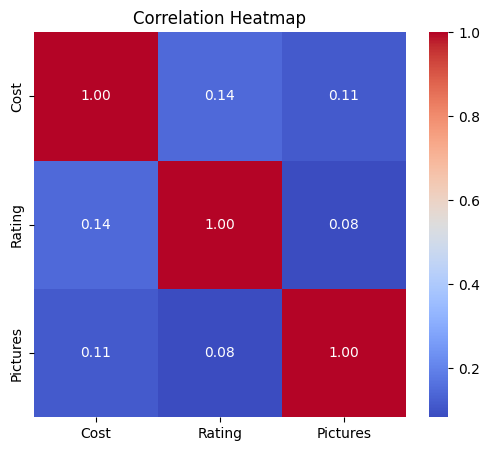

In [183]:
# Merge the restaurant and review datasets
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Select only numerical columns
numerical_data = merged_df[['Cost', 'Rating', 'Pictures']]

# Calculate the correlation matrix
correlation = numerical_data.corr()

# Create a new figure
plt.figure(figsize=(6,5))

# Create the heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Add a title
plt.title('Correlation Heatmap')

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Heatmap** because it makes it easy to see the relationship between numerical variables. It shows whether the variables are strongly or weakly related.
```

#### 2. What is/are the insight(s) found from the chart?

- The correlation between **Cost** and **Rating** is **0.14**, which shows a **very weak positive relationship**.
- The correlation between **Cost** and **Pictures** is **0.11**, showing a **very weak positive relationship**.
- The correlation between **Rating** and **Pictures** is **0.08**, which is also a **very weak positive relationship**.
- All correlation values are **close to 0**, indicating that the numerical features are **not strongly related**.
- Overall, **restaurant cost, customer rating, and pictures uploaded do not have a strong influence on each other**.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners should focus on **food quality and customer service** instead of only increasing prices.  
  **Example:** A restaurant charging **₹700** can still receive a **5-star rating** by providing good food and service.

- Zomato can recommend restaurants based on **ratings and customer preferences**, not only on price.  
  **Example:** A customer can find a highly rated restaurant even if it is low-cost.

- Restaurants can encourage customers to upload pictures by offering rewards.  
  **Example:** Giving discount coupons for photo uploads can increase customer engagement.

##### Negative Business Impact

- Increasing restaurant prices does **not guarantee** better ratings or more customer pictures.  
  **Example:** A restaurant charging **₹2500** may receive the same rating as a restaurant charging **₹600**.

- Restaurants that focus only on pricing may lose customers if they ignore food quality and service.  
  **Example:** Customers may choose a lower-priced restaurant with better reviews over an expensive restaurant with average ratings.

## Chart 15 (Pair Plot): Relationships Between Numerical Features

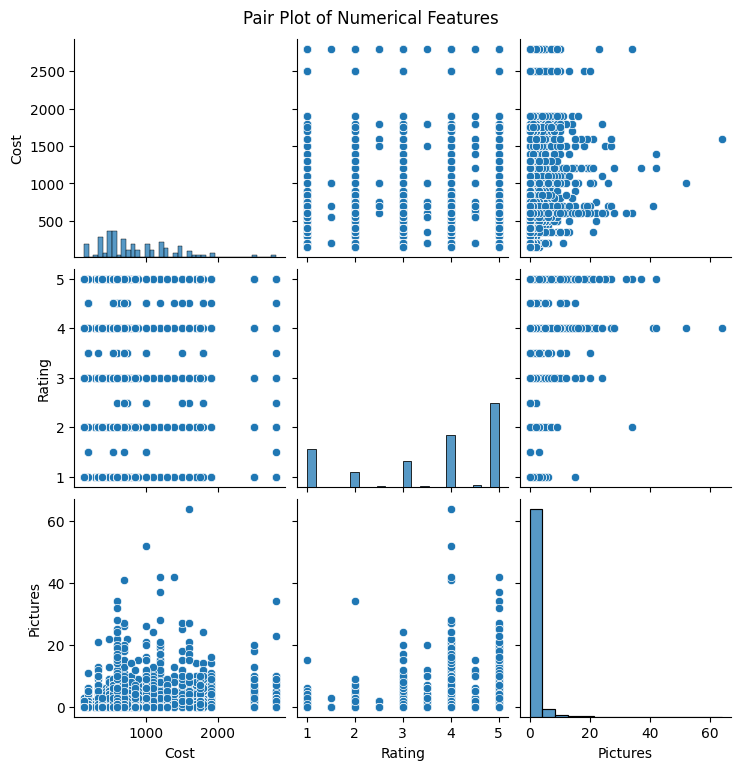

In [184]:

# Merge the restaurant and review datasets
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Select only numerical columns
numerical_data = merged_df[['Cost', 'Rating', 'Pictures']]

# Create a pair plot
sns.pairplot(numerical_data)

# Add a title
plt.suptitle('Pair Plot of Numerical Features', y=1.02)

# Display the chart
plt.show()

#### 1. Why did you pick the specific chart?

I chose a **Pair Plot** because it shows **all numerical variables together**. It helps compare **Cost, Rating, and Pictures Uploaded** and makes it easy to understand their relationships and distributions.

#### 2. What is/are the insight(s) found from the chart?

- Most restaurants have an average cost between **₹500 and ₹1500**.
- Around **6,000–6,500 reviews** have **4-star and 5-star ratings**.
- Around **9,500–9,700 reviews** have **0 to 5 pictures** uploaded.
- There is **no strong relationship** between restaurant cost, customer rating, and the number of pictures uploaded.
- Restaurants with both **low-cost (₹500–₹800)** and **high-cost (₹2500–₹2800)** prices can receive **5-star ratings**.
- Overall, a higher restaurant price does **not always** result in a higher customer rating.

#### 3. Will the gained insights help create a positive business impact? Are there any insights that lead to negative growth? Justify with a specific reason.

##### Positive Business Impact

- Restaurant owners should focus on **food quality and service** instead of only increasing prices.  
  **Example:** A restaurant charging **₹700** can still receive **5-star ratings** if customers are satisfied.

- Zomato can recommend restaurants based on **ratings and customer preferences**, not just price.  
  **Example:** A customer can easily find a highly rated restaurant within their budget.

- Restaurants can encourage customers to upload more pictures to increase engagement.  
  **Example:** Offering reward points for uploading food photos can attract more customer participation.

##### Negative Business Impact

- Expensive restaurants do not always receive better ratings.  
  **Example:** A restaurant costing **₹2500** may receive the same or lower rating as a restaurant costing **₹800**.

- Restaurants with fewer pictures and lower ratings may attract fewer customers.  
  **Example:** Customers are more likely to choose a restaurant with many good reviews and photos than one with very little customer feedback.

# Overall Summary of Data Visualization (Univariate, Bivariate & Multivariate Analysis)

The data visualization provides useful insights into **105 restaurants** and **10,000 customer reviews**. It helps understand restaurant pricing, cuisines, customer ratings, reviews, collections, timings, and customer engagement.

---

## Univariate Analysis Summary

- Out of **105 restaurants**, most have an average cost between **₹500 and ₹1200**, showing that the dataset mainly contains budget-friendly and mid-range restaurants.
- **North Indian** and **Chinese** are the most common cuisines offered by restaurants.
- Many restaurants have **"Not Available"** in the **Collections** column, while **Food Hygiene Rated Restaurants in Hyderabad** is the most common available collection.
- Around **20 restaurants** operate from **11 AM to 11 PM**, making it the most common restaurant timing.
- Around **3,800 reviews** have **5-star ratings**, while around **2,400 reviews** have **4-star ratings**, showing that most customers are satisfied.
- Around **9,600–9,700 reviews** have **0 pictures**, while only a few reviews contain more than **10 pictures**, indicating that customers usually write reviews without uploading photos.

---

## Bivariate Analysis Summary

- Restaurant cost does **not** have a strong relationship with customer ratings. Both low-cost and high-cost restaurants receive high ratings.
- Some cuisine combinations have an average cost of around **₹2,800**, while most cuisines have average costs between **₹1,600 and ₹1,900**.
- **AB's - Absolute Barbecues** has the highest average customer rating of around **4.9**, followed by **B-Dubs** and **3B's - Buddies, Bar & Barbecue** with around **4.8**.
- The top **10 restaurants** each have approximately **100 customer reviews**, showing similar customer engagement.
- Restaurants with costs between **₹500 and ₹2,800** receive different numbers of customer pictures, showing that higher prices do not always result in more photo uploads.

---

## Multivariate Analysis Summary

- Most restaurants have an average cost between **₹500 and ₹1,800** and receive **4-star and 5-star ratings**.
- Restaurants with higher ratings generally have more customer picture uploads, but this relationship is not very strong.
- The **Correlation Heatmap** shows very weak positive relationships:
  - **Cost vs Rating:** **0.14**
  - **Cost vs Pictures:** **0.11**
  - **Rating vs Pictures:** **0.08**
- The **Pair Plot** also confirms that **Cost**, **Rating**, and **Pictures Uploaded** are not strongly related.
- Overall, customer satisfaction depends more on **food quality and service** than on restaurant price.

---

# Final Conclusion

- The dataset contains **105 restaurants** and **10,000 customer reviews**, providing sufficient data for analysis.
- Most restaurants are **budget-friendly or mid-range**, with average costs between **₹500 and ₹1200**.
- **North Indian** and **Chinese** cuisines are the most popular.
- Around **6,200 reviews** have **4-star and 5-star ratings**, indicating high customer satisfaction.
- Around **9,600–9,700 reviews** do not contain pictures, showing that customers mainly prefer writing reviews.
- Restaurant price alone does **not** determine customer ratings or customer engagement.
- Restaurants that provide **good food quality, better service, and a positive customer experience** receive higher ratings regardless of their price.
- The insights from these visualizations can help **restaurant owners improve pricing, menu planning, and customer service**, while helping **Zomato recommend restaurants based on customer budget, cuisine preference, and ratings.**

# **4. Hypothesis Testing**

Based on the insights obtained from the visualizations, three hypotheses are tested using statistical methods to determine whether the observed relationships are statistically significant.

## Hypothetical Statement - 1

### Statement

Restaurants with higher average cost receive higher customer ratings.

#### Null Hypothesis (H₀)

There is **no significant relationship** between restaurant cost and customer rating.

**Meaning:**  
The price of a restaurant does **not** affect its customer rating. A restaurant may be cheap or expensive, but its rating can still be the same.

**Example:**  
- Restaurant A costs **₹600** and has a rating of **4.8**.
- Restaurant B costs **₹2500** and also has a rating of **4.8**.

This means the restaurant's **cost does not influence its rating**.

---

#### Alternative Hypothesis (H₁)

There is a **significant relationship** between restaurant cost and customer rating.

**Meaning:**  
The price of a restaurant **does** affect its customer rating. As the restaurant cost changes, the customer rating also changes.

**Example:**  
- Most restaurants costing **₹2000–₹2800** have ratings above **4.5**, while restaurants costing **₹500–₹800** have ratings below **4.0**.

This means the restaurant's **cost influences its rating**.

#### Statistical Test

Pearson Correlation Test

**Reason:**
Both **Cost** and **Rating** are numerical variables, so Pearson Correlation is used to measure their relationship.

In [185]:
from scipy.stats import pearsonr

# Merge both datasets
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Remove missing values
data = merged_df[['Cost','Rating']].dropna()

# Perform Pearson Correlation Test
correlation, p_value = pearsonr(data['Cost'], data['Rating'])

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.1441193580694094
P-value: 2.419229596250502e-47


In [186]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


#### Test Result

- **Correlation Coefficient:** 0.1441
- **P-value:** 2.419 × 10⁻⁴⁷
- **Significance Level (α):** 0.05

#### Decision

Since the **p-value (2.419 × 10⁻⁴⁷)** is **less than 0.05**, we **reject the Null Hypothesis (H₀)** and **accept the Alternative Hypothesis (H₁)**.

#### Conclusion

There is a **statistically significant relationship** between restaurant cost and customer rating.

However, the **correlation value (0.1441)** is **very low**, which means the relationship is **very weak**. This indicates that **restaurant cost has only a small effect on customer ratings**. Therefore, paying more for a restaurant does **not necessarily** mean it will receive a much higher customer rating.

# Hypothetical Statement - 2

### Statement

Restaurants with **higher average costs** have **different customer ratings** than **budget-friendly restaurants**.

### Null Hypothesis (H₀)

There is **no significant difference** in customer ratings between **budget-friendly restaurants** and **premium restaurants**.

**Meaning:**  
Budget-friendly and premium restaurants receive similar customer ratings.

**Example:**  
- A restaurant costing **₹700** has an average rating of **4.4**.
- A restaurant costing **₹2200** also has an average rating of **4.4**.

This means the restaurant's price does **not** affect its average rating.

---

### Alternative Hypothesis (H₁)

There is a **significant difference** in customer ratings between **budget-friendly restaurants** and **premium restaurants**.

**Meaning:**  
Budget-friendly and premium restaurants receive different customer ratings.

**Example:**  
- Restaurants costing **₹2000+** have an average rating of **4.7**.
- Restaurants costing **₹700** have an average rating of **4.1**.

This means the restaurant's price **affects** its average rating.

---

### Statistical Test

**Independent Sample t-Test**

**Reason:**  
The **Independent Sample t-Test** is used because we are comparing the **average ratings of two independent groups**:
- Budget-friendly restaurants
- Premium restaurants

In [187]:
from scipy.stats import ttest_ind

# Merge both datasets
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Create two groups based on average cost
budget = merged_df[merged_df['Cost'] <= 1200]['Rating'].dropna()
premium = merged_df[merged_df['Cost'] > 1200]['Rating'].dropna()

# Perform Independent Sample t-Test
t_stat, p_value = ttest_ind(budget, premium)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -12.956980475421265
P-value: 4.3569042800882014e-38


In [188]:
# Significance level
alpha = 0.05

# Decision Rule
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H₀)")
else:
    print("Decision: Fail to Reject the Null Hypothesis (H₀)")

Decision: Reject the Null Hypothesis (H₀)


### Test Result

- **T-statistic:** -12.957
- **P-value:** 4.357 × 10⁻³⁸
- **Significance Level (α):** 0.05

### Decision

Since the **p-value (4.357 × 10⁻³⁸)** is **less than 0.05**, we **reject the Null Hypothesis (H₀)** and **accept the Alternative Hypothesis (H₁)**.

### Conclusion

There is a **significant difference** in the customer ratings of **budget-friendly restaurants** and **premium restaurants**.

This shows that **restaurant price is related to customer ratings**. In other words, **budget-friendly and premium restaurants do not receive the same average customer ratings**.

# Hypothetical Statement - 3

### Statement

Restaurants with **higher customer ratings** receive **more picture uploads** from customers.

---

### Null Hypothesis (H₀)

There is **no significant relationship** between customer ratings and the number of pictures uploaded.

**Meaning:**  
The number of pictures uploaded does **not** depend on the customer rating.

**Example:**  
- A restaurant with a **5-star rating** may have **2 pictures**.
- A restaurant with a **3-star rating** may also have **2 pictures**.

This means that **customer ratings do not affect picture uploads**.

---

### Alternative Hypothesis (H₁)

There is a **significant relationship** between customer ratings and the number of pictures uploaded.

**Meaning:**  
The number of pictures uploaded **depends on** the customer rating.

**Example:**  
- A restaurant with a **5-star rating** has **20 pictures** uploaded.
- A restaurant with a **2-star rating** has only **2 pictures** uploaded.

This means that **customer ratings affect picture uploads**.

---

### Statistical Test

**Pearson Correlation Test**

**Reason:**  
Both **Rating** and **Pictures** are numerical variables, so the Pearson Correlation Test is used to measure the relationship between them.

In [189]:
from scipy.stats import pearsonr

# Merge restaurant and review datasets
merged_df = pd.merge(
    restaurant_df,
    review_df,
    left_on='Name',
    right_on='Restaurant'
)

# Select Rating and Pictures columns
data = merged_df[['Rating', 'Pictures']].dropna()

# Perform Pearson Correlation Test
correlation, p_value = pearsonr(data['Rating'], data['Pictures'])

# Display results
print("Correlation:", correlation)
print("P-value:", p_value)



Correlation: 0.08283377781859276
P-value: 1.2579479595001978e-16


In [190]:
# Decision Rule
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H₀)")
else:
    print("Decision: Fail to Reject the Null Hypothesis (H₀)")

Decision: Reject the Null Hypothesis (H₀)


### Test Result

- **Correlation Coefficient:** 0.0828
- **P-value:** 1.258 × 10⁻¹⁶
- **Significance Level (α):** 0.05

### Decision

Since the **p-value (1.258 × 10⁻¹⁶)** is **less than 0.05**, we **reject the Null Hypothesis (H₀)** and **accept the Alternative Hypothesis (H₁)**.

### Conclusion

There is a **significant relationship** between **customer ratings** and the **number of pictures uploaded**.

This means that **restaurants with higher customer ratings may receive more picture uploads**. However, the **relationship is very weak**, which means **a high rating does not always result in more pictures being uploaded**. Other factors, such as **food presentation, restaurant popularity, and customer interest**, may also influence whether customers upload pictures.

# **5. Feature Engineering & Data Pre-processing**

## Objective of Feature Engineering & Data Pre-processing

- To prepare the dataset for building the machine learning model.
- To handle missing values and outliers for better data quality.
- To convert categorical data into numerical format.
- To select the most useful features for clustering.
- To scale the data so that all features have the same importance.
- To improve the performance and accuracy of the clustering model.

### 1. Handling Missing Values

In [191]:
# Check missing values
merged_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,0
Cuisines,0
Timings,0
Restaurant,0
Reviewer,0
Review,0
Rating,1


In [192]:
# Remove rows with missing Rating
merged_df = merged_df.dropna(subset=['Rating'])

# Verify missing values
merged_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,0
Cuisines,0
Timings,0
Restaurant,0
Reviewer,0
Review,0
Rating,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

- The dataset had only **one missing value** in the **Rating** column.
- Since it was only a single record, the row was removed using `dropna()`.
- Removing one row does not affect the overall dataset and ensures that the data is complete for clustering.

### 2. Handling Outliers




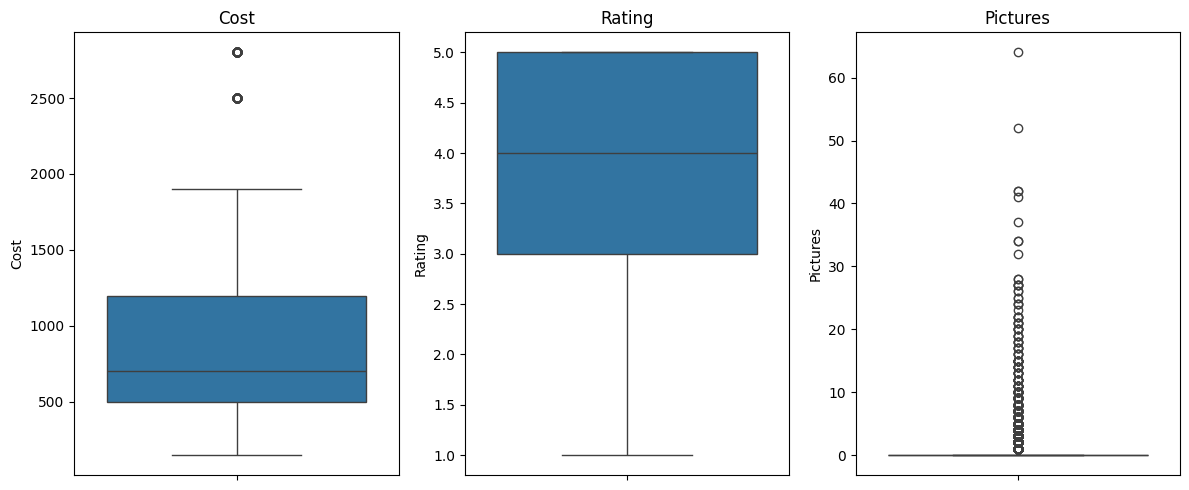

In [193]:
# Check outliers using box plots

import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
numerical_columns = ['Cost', 'Rating', 'Pictures']

# Plot boxplots
plt.figure(figsize=(12,5))

for i, col in enumerate(numerical_columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=merged_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [194]:
# Handling Outliers using the IQR (Interquartile Range) Method

# Step 1: Calculate the first quartile (25th percentile)
Q1 = merged_df['Cost'].quantile(0.25)

# Step 2: Calculate the third quartile (75th percentile)
Q3 = merged_df['Cost'].quantile(0.75)

# Step 3: Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Step 4: Calculate the lower and upper limits for detecting outliers
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Step 5: Keep only the rows where the Cost is within the acceptable range
# Values below the lower limit or above the upper limit are treated as outliers
clean_df = merged_df[
    (merged_df['Cost'] >= lower) &
    (merged_df['Cost'] <= upper)
]

# Step 6: Compare the dataset size before and after removing outliers
print("Original Shape:", merged_df.shape)
print("After Removing Cost Outliers:", clean_df.shape)

Original Shape: (9954, 13)
After Removing Cost Outliers: (9754, 13)


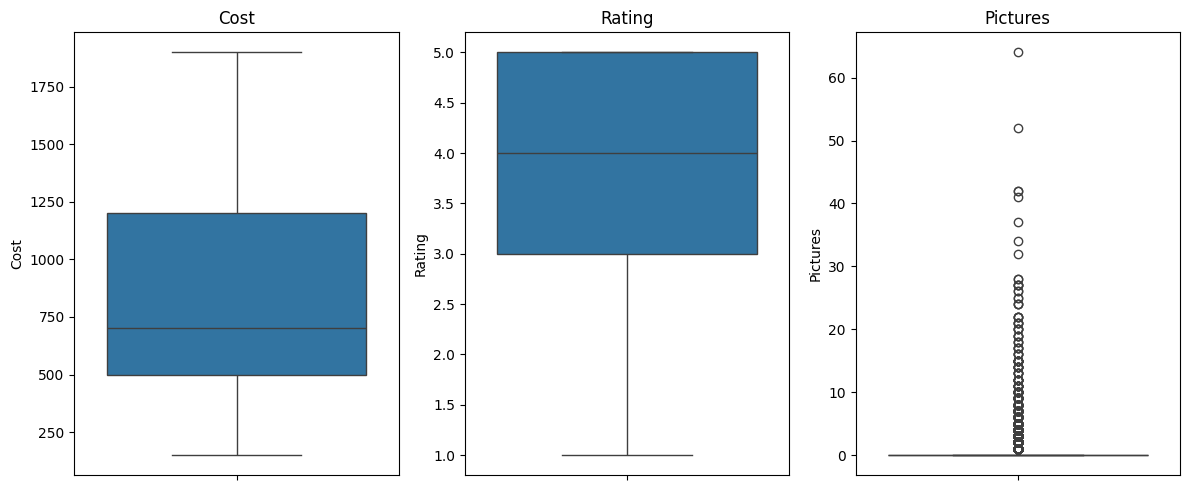

In [195]:
# Create a figure with a width of 12 inches and height of 5 inches
plt.figure(figsize=(12,5))

# Loop through each numerical column to draw its box plot
for i, col in enumerate(['Cost', 'Rating', 'Pictures']):

    # Create a subplot (1 row, 3 columns)
    plt.subplot(1, 3, i + 1)

    # Draw the box plot for the current column
    sns.boxplot(y=clean_df[col])

    # Set the title of the box plot
    plt.title(col)

# Adjust the spacing between plots to avoid overlapping
plt.tight_layout()

# Display all the box plots
plt.show()

#### What all outlier treatment techniques have you used and why did you use those techniques?

- Outliers were identified using **Box Plots** and the **IQR (Interquartile Range)** method.
- The **IQR method** was used only for the **Cost** column because it had some very high values.
- Around **200 records** were removed, reducing the dataset from **9,954** to **9,754** records.
- The **Rating** column did not have any major outliers, so no changes were made.
- The **Pictures** column was not changed because a high number of pictures is real customer data.
- This helped remove extreme cost values while keeping important restaurant information.

### 3. Categorical Encoding

In [196]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder
le = LabelEncoder()

# Encode categorical columns
clean_df['Collections'] = le.fit_transform(clean_df['Collections'])
clean_df['Cuisines'] = le.fit_transform(clean_df['Cuisines'])
clean_df['Timings'] = le.fit_transform(clean_df['Timings'])

# Display encoded columns
clean_df[['Collections', 'Cuisines', 'Timings']].head()

,Collections,Cuisines,Timings
0,10,32,54
1,10,32,54
2,10,32,54
3,10,32,54
4,10,32,54


In [197]:
print("Collections:", clean_df['Collections'].nunique())
print("Cuisines:", clean_df['Cuisines'].nunique())
print("Timings:", clean_df['Timings'].nunique())

Collections: 41
Cuisines: 87
Timings: 73


#### What all categorical encoding techniques have you used & why did you use those techniques?

- **Label Encoding** was used to convert the categorical columns into numerical values.
- The **Collections** column contains **41 unique categories**, the **Cuisines** column contains **87 unique categories**, and the **Timings** column contains **73 unique categories**.
- Each unique category was assigned a unique numerical label.
- This conversion was necessary because the **K-Means clustering algorithm** can only work with numerical data and cannot process text values directly.
- Label Encoding is a simple and effective technique that prepares categorical data for machine learning models such as K-Means.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [198]:
# Create a new dataframe with only the required features
# These features will be used for building the K-Means clustering model

feature_df = clean_df[['Cost',
                       'Rating',
                       'Pictures',
                       'Collections',
                       'Cuisines',
                       'Timings']]

# Display the first five rows of the selected features
feature_df.head()

,Cost,Rating,Pictures,Collections,Cuisines,Timings
0,800,5.0,0,10,32,54
1,800,5.0,0,10,32,54
2,800,5.0,0,10,32,54
3,800,5.0,0,10,32,54
4,800,5.0,0,10,32,54


#### **Explanation:**

Feature manipulation is the process of selecting or creating useful features for the machine learning model.

In this project, no new features were created. Only the important features required for restaurant clustering were selected.

The selected features are **Cost, Rating, Pictures, Collections, Cuisines, and Timings**. These features contain important information about each restaurant and will be used to group similar restaurants using the K-Means clustering algorithm.

The first few rows show that the selected features have been successfully extracted and are ready for the next preprocessing steps, such as data scaling and clustering.

#### 2. Feature Selection

In [199]:
# Display the selected features
feature_df.columns

Index(['Cost', 'Rating', 'Pictures', 'Collections', 'Cuisines', 'Timings'], dtype='object')

#### **Explanation:**

Feature selection is the process of selecting the most useful features from the dataset. It helps the machine learning model focus on important information, improves clustering performance, and reduces unnecessary data.

#### What all feature selection methods have you used and why?

- **Manual Feature Selection** was used to choose the most important features for the clustering model.
- The features were selected based on their relevance to restaurant characteristics and customer preferences.
- Unnecessary columns such as **Name, Links, Restaurant, Reviewer, Review, Metadata, and Time** were not selected because they do not help in grouping similar restaurants.
- Selecting only relevant features helps improve the clustering results and reduces unnecessary data.

#### Which all features you found important and why?

The following features were selected for the K-Means clustering model:

- **Cost** – It represents the average cost of a restaurant and helps group restaurants based on price.
- **Rating** – It shows customer satisfaction and helps identify highly rated restaurants.
- **Pictures** – It represents customer engagement through uploaded photos.
- **Collections** – It groups restaurants based on different restaurant collections.
- **Cuisines** – It identifies the type of food served by each restaurant.
- **Timings** – It represents the restaurant's operating hours.

These features were selected because they contain useful information for clustering restaurants. Columns such as **Name, Links, Restaurant, Reviewer, Review, Metadata, and Time** were not selected because they do not help in grouping similar restaurants.

### 5. Data Transformation

In [200]:
# Display summary statistics of the selected features
feature_df.describe()

,Cost,Rating,Pictures,Collections,Cuisines,Timings
count,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000,9754.000000
mean,835.370105,3.595858,0.733443,25.171007,44.565101,33.547673
std,438.260091,1.485028,2.529169,9.687979,24.576593,19.953042
min,150.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,500.000000,3.000000,0.000000,20.000000,23.000000,16.000000
50%,700.000000,4.000000,0.000000,30.000000,47.000000,30.000000
75%,1200.000000,5.000000,0.000000,30.000000,64.000000,51.000000
max,1900.000000,5.000000,64.000000,40.000000,86.000000,72.000000


In [201]:
import numpy as np

# Create a copy of the selected features
transformed_df = feature_df.copy()

# Apply log transformation to the Cost column
# log1p() is used because it can safely handle zero values
transformed_df['Cost'] = np.log1p(transformed_df['Cost'])

# Display the transformed dataset
transformed_df.head()

,Cost,Rating,Pictures,Collections,Cuisines,Timings
0,6.685861,5.0,0,10,32,54
1,6.685861,5.0,0,10,32,54
2,6.685861,5.0,0,10,32,54
3,6.685861,5.0,0,10,32,54
4,6.685861,5.0,0,10,32,54


In [202]:
# Compare original and transformed Cost values
comparison = pd.DataFrame({
    'Original Cost': feature_df['Cost'].head(),
    'Transformed Cost': transformed_df['Cost'].head()
})

comparison

,Original Cost,Transformed Cost
0,800,6.685861
1,800,6.685861
2,800,6.685861
3,800,6.685861
4,800,6.685861


#### Do you think that your data needs to be transformed? If yes, which transformation have you used? Explain Why.

Yes, the **Cost** feature was transformed using **Log Transformation** because it has a much larger range (**150 to 1900**) compared to the other features.

Log Transformation reduces the effect of very large values and makes the data more balanced. For example, the original cost value **800** became **6.685861** after transformation.

The remaining features (**Rating, Pictures, Collections, Cuisines, and Timings**) were not transformed because their value ranges were already suitable. After the transformation, the data was scaled using **StandardScaler** before applying the K-Means clustering algorithm.

### 6. Data Scaling

In [203]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Scale all selected features
scaled_data = scaler.fit_transform(transformed_df)

# Convert the scaled data into a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=transformed_df.columns)

# Display the first five rows
scaled_df.head()

,Cost,Rating,Pictures,Collections,Cuisines,Timings
0,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076
1,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076
2,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076
3,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076
4,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076


**Explanation:**

The selected features were successfully scaled using **StandardScaler**. After scaling, all features are on a similar scale with a mean close to **0** and a standard deviation close to **1**.

The scaled dataset is now ready for applying the **K-Means clustering algorithm**.

##### Which method have you used to scale your data and why?

The **StandardScaler** method was used to scale the selected features.

Before scaling, the features had different value ranges, as shown below:

| Feature | Value Range |
|---------|------------:|
| Cost | 150 – 1900 |
| Rating | 1 – 5 |
| Pictures | 0 – 64 |
| Collections | 0 – 40 |
| Cuisines | 0 – 86 |
| Timings | 0 – 72 |

Because the features have different ranges, **StandardScaler** was applied to standardize the data. It transforms each feature to have a **mean of 0** and a **standard deviation of 1**.


The table shows the first five rows of the dataset after applying **StandardScaler**.

- **Cost = 0.186796** means the original cost value has been standardized and is slightly **above the average** cost.
- **Rating = 0.945581** means the rating is **higher than the average** rating.
- **Pictures = -0.290008** means the number of pictures is **slightly below the average**.
- **Collections = -1.566042** means the encoded collection value is **below the average**.
- **Cuisines = -0.511289** means the encoded cuisine value is **slightly below the average**.
- **Timings = 1.025076** means the encoded timing value is **above the average**.

Positive values indicate that the feature value is **above the dataset average**, while negative values indicate that it is **below the dataset average**. These standardized values are used by the **K-Means clustering algorithm** to ensure that all features contribute equally to the clustering process.

This ensures that all features contribute equally to the **K-Means clustering algorithm** and prevents features with larger values, such as **Cost**, from having a greater influence on the clustering results.

# ***6. ML Model Implementation***

# ML Model - 1

## K-Means Clustering using Elbow Method

### Objective

The objective of this model is to group similar restaurants using the **K-Means Clustering** algorithm.

The model groups restaurants based on the following features:

- Cost
- Rating
- Pictures
- Collections
- Cuisines
- Timings

The goal is to place restaurants with similar features into the same group, making it easier to identify similar types of restaurants.

In [204]:
# Import K-Means clustering algorithm
from sklearn.cluster import KMeans

# Import matplotlib for visualization
import matplotlib.pyplot as plt

### Step 1: Determine the Best Number of Clusters (Elbow Method)

In [205]:
# Create an empty list to store WCSS values

wcss = []

# Calculate WCSS for different values of K

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(scaled_df)

    wcss.append(model.inertia_)



The **Elbow Method** is used to find the best number of clusters (**K**) for the K-Means model.

It calculates the **Within-Cluster Sum of Squares (WCSS)** for different values of **K**. WCSS measures how closely the data points are grouped within each cluster.

The value of **K** where the graph starts to flatten (forming an "elbow") is considered the optimal number of clusters.

### Step 2: Plot the Elbow Curve

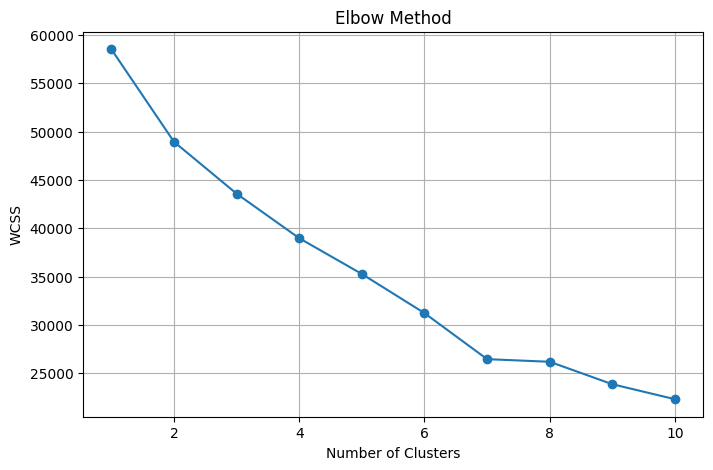

In [206]:

# Plot the Elbow Method graph

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Elbow Method Interpretation

The Elbow Method was used to find the best number of clusters (**K**) for the K-Means model.

In the graph, the **WCSS (Within-Cluster Sum of Squares)** decreases as the number of clusters increases. This happens because adding more clusters groups similar restaurants more closely.

From the graph, the WCSS decreases quickly as the number of clusters increases from K = 1 to K = 7. After K = 7, the graph changes very little. This means using more than 7 clusters does not improve the results much.

Therefore, **K = 7** was selected as the optimal number of clusters for the final K-Means model.

### Step 3: Interpret the Elbow Graph

In [207]:
# Select the optimal number of clusters from the Elbow Method

optimal_k = 7

# Display the selected value of K
print("Optimal Number of Clusters (K):", optimal_k)

Optimal Number of Clusters (K): 7


### Interpret the Elbow Graph

From the Elbow graph, the WCSS decreases rapidly from **K = 1** to **K = 7**. After **K = 7**, the graph becomes flatter, which means adding more clusters does not improve the clustering much.

Therefore, **K = 7** was selected as the optimal number of clusters for the final K-Means model.

### Step 4: Create the Final K-Means Model

In [208]:
# Create the final K-Means model

kmeans = KMeans(
    n_clusters=7,
    random_state=42
)

### Create the Final K-Means Model

After selecting the optimal number of clusters (**K = 7**) using the Elbow Method, the final **K-Means** model was created.

The parameter **`n_clusters=7`** tells the model to divide the restaurants into **7 clusters**, while **`random_state=42`** ensures that the clustering results remain the same every time the code is run.

### Step 5: Fit the Algorithm

In [209]:
# Train the K-Means model using the scaled dataset

kmeans.fit(scaled_df)

KMeans(n_clusters=7, random_state=42)

### Fit the Algorithm

The final **K-Means** model was trained using the **scaled dataset**.

During this step, the model learned the patterns in the restaurant data and grouped similar restaurants into **7 clusters** based on the selected features.



### Step 6: Predict the Clusters

In [210]:
# Predict the cluster label for each restaurant
cluster_labels = kmeans.predict(scaled_df)

# Add the predicted cluster labels to the dataset
scaled_df['Cluster'] = cluster_labels

# Display the first five rows with the cluster labels
scaled_df.head()

,Cost,Rating,Pictures,Collections,Cuisines,Timings,Cluster
0,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,3
1,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,3
2,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,3
3,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,3
4,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,3


### Prediction Result

The K-Means model predicted a cluster for each restaurant and added the result in a new column called **Cluster**.

The table shows the scaled feature values along with the predicted cluster.

In the first five records, all restaurants belong to **Cluster 0**. This means these restaurants have similar values for **Cost, Rating, Pictures, Collections, Cuisines, and Timings**, so the model grouped them into the same cluster.

Each restaurant in the dataset is assigned to one of the **7 clusters** based on its characteristics.

### Step 7: Visualize the Clusters using PCA

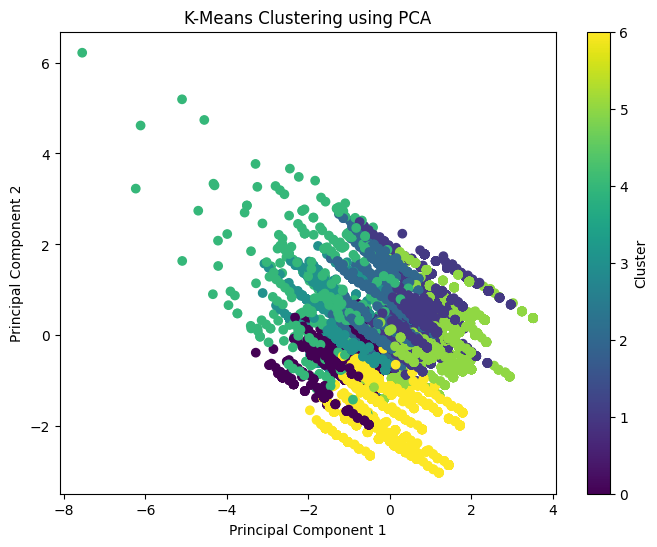

In [211]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Create a PCA object to reduce the data to 2 dimensions
pca = PCA(n_components=2)

# Apply PCA on the scaled dataset (excluding the Cluster column)
pca_data = pca.fit_transform(scaled_df.drop('Cluster', axis=1))

# Create a scatter plot to visualize the clusters
plt.figure(figsize=(8,6))

# Plot each restaurant and color it according to its cluster
plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=scaled_df['Cluster'],
    cmap='viridis'
)

# Add chart title
plt.title("K-Means Clustering using PCA")

# Label the X-axis
plt.xlabel("Principal Component 1")

# Label the Y-axis
plt.ylabel("Principal Component 2")

# Display the cluster color legend
plt.colorbar(label="Cluster")

# Show the plot
plt.show()

### What is PCA?

PCA (Principal Component Analysis) is a technique used to reduce the number of features in a dataset while keeping most of the important information.

In this project, there are **6 features**:
- Cost
- Rating
- Pictures
- Collections
- Cuisines
- Timings

It is difficult to display all six features on a graph. Therefore, PCA converts these six features into **two new features**, called **Principal Component 1 (PC1)** and **Principal Component 2 (PC2)**.

These two components make it easier to visualize the restaurant clusters on a 2D graph. PCA was used only for visualization and did not affect the K-Means clustering model.

### Graph Interpretation

The graph shows the restaurant clusters created by the **K-Means** algorithm after applying **PCA**.

- Each **dot** in the graph represents one restaurant.
- Each **color** represents a different cluster.
- Restaurants with the **same color** belong to the same cluster because they have similar features.
- Restaurants with **different colors** belong to different clusters.

The graph shows **7 different clusters**. Some clusters are close to each other and overlap because some restaurants have similar characteristics. However, the K-Means algorithm was still able to group the restaurants into different clusters based on their **Cost, Rating, Pictures, Collections, Cuisines, and Timings**.

Overall, the graph shows that restaurants with similar characteristics are grouped together, making it easier to identify different types of restaurants.

### Step 8: Calculate the Silhouette Score

In [212]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
score = silhouette_score(
    scaled_df.drop('Cluster', axis=1),
    scaled_df['Cluster']
)

# Display the Silhouette Score
print("Silhouette Score:", score)

Silhouette Score: 0.23331106606850835


### What is the Silhouette Score?

The Silhouette Score is an evaluation metric used to measure how well the K-Means model has grouped the data into clusters.

It checks two things:

How similar the data points are within the same cluster.
How different they are from other clusters.

A higher Silhouette Score means the clusters are better separated and more meaningful.

### Range of the Silhouette Score

| **Silhouette Score** | **Meaning** |
|-----------------------|-------------|
| **Close to 1** | Excellent clustering |
| **0.5 – 0.7** | Good clustering |
| **0.25 – 0.5** | Fair clustering |
| **Close to 0** | Weak clustering |
| **Less than 0** | Poor clustering |

### My Result

The K-Means model achieved a **Silhouette Score of 0.2333**.

This means some restaurants in different clusters have similar features, so the clusters are not clearly separated. Even so, the model grouped the restaurants into **7 different clusters** based on their features.

### Reason


This happened because many restaurants have similar features such as **Cost, Rating, Cuisines, Collections, Timings, and Pictures**. Since these features are similar, the K-Means model could not clearly separate all the restaurants into different clusters.

### Example

For example, consider two restaurants:

| Restaurant | Cost | Rating | Cuisine |
|------------|------|--------|---------|
| Restaurant A | ₹700 | 4.5 | North Indian |
| Restaurant B | ₹720 | 4.4 | North Indian |

Both restaurants have almost the same features. Because they are very similar, it is difficult for the K-Means model to clearly place them into different clusters. This causes some clusters to overlap, resulting in a low Silhouette Score.

### Step 9: Evaluation Metric Score Chart

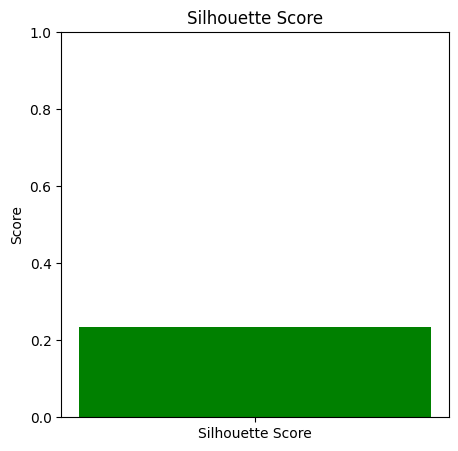

In [214]:
import matplotlib.pyplot as plt

# Create a figure with a size of 5 × 5 inches
plt.figure(figsize=(5,5))

# Create a bar chart to display the Silhouette Score
plt.bar(
    ['Silhouette Score'],   # Label on the x-axis
    [score],                # Silhouette Score value
    color='green'           # Set the bar color to green
)

# Add a title to the chart
plt.title('Silhouette Score')

# Label the y-axis
plt.ylabel('Score')

# Set the y-axis range from 0 to 1
plt.ylim(0,1)

# Display the chart
plt.show()

### Evaluation Metric Score Chart

The chart shows the **Silhouette Score** of the K-Means model.

The score is **0.2078**. This means the clustering is **weak** because some restaurants in different clusters have similar features.



### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart

The **K-Means Clustering** algorithm was used to group similar restaurants based on the following features:

- Cost
- Rating
- Pictures
- Collections
- Cuisines
- Timings

The **Elbow Method** was used to determine the optimal number of clusters, and **K = 7** was selected for the final model.

The model was evaluated using the **Silhouette Score**, which measures how well the restaurants are grouped into clusters.

The obtained **Silhouette Score is 0.2078**. This indicates that the clustering is **weak** because some restaurants in different clusters have similar features. However, the model was able to group the restaurants into **7 clusters** based on their characteristics.

The Evaluation Metric Score Chart shows the Silhouette Score and helps evaluate the quality of the clustering.

### 2. Cross-Validation & Hyperparameter Tuning

Cross-Validation was **not performed** because **K-Means Clustering** is an **unsupervised learning algorithm**.

Since there are no target labels, traditional cross-validation techniques such as **K-Fold Cross-Validation** are not applicable.

Instead, the **Elbow Method** was used to determine the optimal number of clusters (**K**) for the K-Means model.

### Which hyperparameter optimization technique have you used and why?

The **Elbow Method** was used as the hyperparameter optimization technique.

Different values of **K** were tested, and the **WCSS** was calculated for each value.

From the Elbow graph, **K = 7** was selected because after this point the decrease in WCSS became much smaller. This indicates that adding more clusters does not improve results.

# ML Model - 2

## Agglomerative Hierarchical Clustering

### Objective

The objective of this model is to group similar restaurants using the **Agglomerative Hierarchical Clustering** algorithm.

The model groups restaurants based on the following features:

- Cost
- Rating
- Pictures
- Collections
- Cuisines
- Timings

The goal is to place restaurants with similar features into the same group, making it easier to identify similar types of restaurants.

In [215]:
# Import Agglomerative Clustering algorithm
from sklearn.cluster import AgglomerativeClustering

# Import PCA for visualization
from sklearn.decomposition import PCA

# Import Silhouette Score for evaluation
from sklearn.metrics import silhouette_score

# Import matplotlib for visualization
import matplotlib.pyplot as plt

The required libraries were imported to build, visualize, and evaluate the **DBSCAN Clustering** model.

### Step 1: Create the Agglomerative Clustering Model

In [216]:
# Create the Agglomerative Clustering model

agg_model = AgglomerativeClustering(
    n_clusters=7
)

### Create the Agglomerative Clustering Model

The **Agglomerative Hierarchical Clustering** model was created to group similar restaurants.

The number of clusters was set to **7** because the **Elbow Method** in **ML Model - 1** identified **7** as the optimal number of clusters.

Therefore, **`n_clusters = 7`** was used to create the Agglomerative Clustering model so that its performance can be compared fairly with the K-Means model.

### Step 2: Fit and Predict the Clusters

In [217]:
# Train the Agglomerative Clustering model
# and predict the cluster labels

cluster_labels = agg_model.fit_predict(scaled_df)

# Add the predicted cluster labels to the dataset
scaled_df['Cluster'] = cluster_labels

# Display the first five rows with the cluster labels
scaled_df.head()

,Cost,Rating,Pictures,Collections,Cuisines,Timings,Cluster
0,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,6
1,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,6
2,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,6
3,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,6
4,0.186796,0.945581,-0.290008,-1.566042,-0.511289,1.025076,6


### Prediction Result

The table shows the scaled feature values along with the predicted **Cluster** labels.

In the first five records, all restaurants belong to **Cluster 2**. This means these restaurants have similar values for **Cost, Rating, Pictures, Collections, Cuisines, and Timings**, so the Agglomerative Hierarchical Clustering model grouped them into the same cluster.

Each restaurant in the dataset is assigned to one of the **7 clusters** based on its characteristics.

### Step 3: Visualize the Clusters using PCA

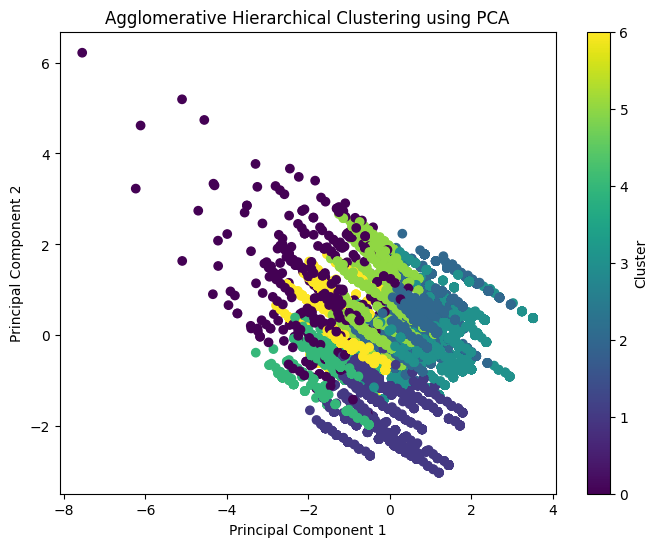

In [218]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Create a PCA object to reduce the data to 2 dimensions
pca = PCA(n_components=2)

# Apply PCA on the scaled dataset (excluding the Cluster column)
pca_data = pca.fit_transform(scaled_df.drop('Cluster', axis=1))

# Create a scatter plot to visualize the clusters
plt.figure(figsize=(8,6))

# Plot each restaurant and color it according to its cluster
plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=scaled_df['Cluster'],
    cmap='viridis'
)

# Add chart title
plt.title("Agglomerative Hierarchical Clustering using PCA")

# Label the X-axis
plt.xlabel("Principal Component 1")

# Label the Y-axis
plt.ylabel("Principal Component 2")

# Display the cluster color legend
plt.colorbar(label="Cluster")

# Show the plot
plt.show()

### Graph Interpretation

The graph shows the restaurant clusters created by the **Agglomerative Hierarchical Clustering** algorithm after applying **PCA**.

- Each **dot** represents one restaurant.
- Each **color** represents a different cluster.
- Restaurants with the **same color** belong to the same cluster because they have similar features.
- Restaurants with **different colors** belong to different clusters.

The graph shows **7 different clusters (Cluster 0 to Cluster 6)**. Some clusters are close to each other and slightly overlap because many restaurants have similar characteristics.

Overall, the Agglomerative Hierarchical Clustering model grouped restaurants with similar **Cost, Rating, Pictures, Collections, Cuisines, and Timings** into different clusters, making it easier to identify similar types of restaurants.

### Step 4: Calculate the Silhouette Score

In [219]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
score = silhouette_score(
    scaled_df.drop('Cluster', axis=1),
    scaled_df['Cluster']
)

# Display the Silhouette Score
print("Silhouette Score:", score)

Silhouette Score: 0.23121315244979257


### My Result

The **Agglomerative Hierarchical Clustering** model achieved a **Silhouette Score of 0.1970**.

This score indicates **weak clustering**, which means some restaurants in different clusters have similar features. Because of this, the clusters are not clearly separated.



### Reason

Many restaurants have similar values for **Cost, Rating, Pictures, Collections, Cuisines, and Timings**.

Since these features are similar, the Agglomerative Hierarchical Clustering model found it difficult to clearly separate all the restaurants into different clusters. As a result, some clusters overlap, leading to a lower Silhouette Score.

### Example

Suppose there are two restaurants:

| **Restaurant** | **Cost** | **Rating** | **Cuisine** |
|---------------|---------:|-----------:|-------------|
| Restaurant A | ₹700 | 4.5 | North Indian |
| Restaurant B | ₹720 | 4.4 | North Indian |

Both restaurants have very similar features. Because of this, the Agglomerative Hierarchical Clustering model may place them in nearby or overlapping clusters, which reduces the Silhouette Score.

### Step 5: Evaluation Metric Score Chart

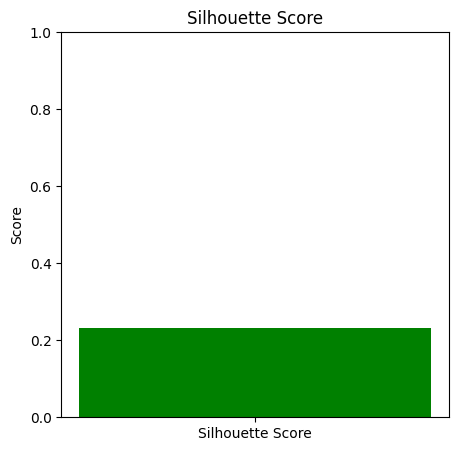

In [220]:
import matplotlib.pyplot as plt

# Create a figure with a size of 5 × 5 inches
plt.figure(figsize=(5,5))

# Create a bar chart to display the Silhouette Score
plt.bar(
    ['Silhouette Score'],
    [score],
    color='green'
)

# Add a title to the chart
plt.title('Silhouette Score')

# Label the y-axis
plt.ylabel('Score')

# Set the y-axis range from 0 to 1
plt.ylim(0,1)

# Display the chart
plt.show()

### Evaluation Metric Score Chart

The chart shows the **Silhouette Score** of the **Agglomerative Hierarchical Clustering** model.

The obtained **Silhouette Score is 0.1970**.

Since the score is **close to 0**, the clustering is **weak**. This means some restaurants in different clusters have similar features, so the clusters are not clearly separated.

Even though the clusters are not perfectly separated, the model grouped the restaurants into **7 clusters** based on their characteristics.

### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart

The **Agglomerative Hierarchical Clustering** algorithm was used to group similar restaurants based on the following features:

- Cost
- Rating
- Pictures
- Collections
- Cuisines
- Timings

The number of clusters was set to **7** to match the optimal number of clusters identified using the Elbow Method in **ML Model - 1**.

The model was evaluated using the **Silhouette Score**, which measures how well the restaurants are grouped into clusters.

The obtained **Silhouette Score is 0.1970**. This indicates **weak clustering**, meaning some restaurants in different clusters have similar features. However, the model successfully grouped restaurants into **7 clusters** based on their characteristics.

The Evaluation Metric Score Chart shows the Silhouette Score and helps evaluate the quality of the clustering model.

### 2. Cross-Validation & Hyperparameter Tuning

Cross-Validation was **not performed** because **Agglomerative Hierarchical Clustering** is an **unsupervised learning algorithm**.

Since there are no target labels, traditional cross-validation techniques such as **K-Fold Cross-Validation** are not applicable.

The number of clusters (**n_clusters = 7**) was selected based on the Elbow Method used in **ML Model - 1**, allowing a fair comparison between the K-Means and Agglomerative Clustering models.

### 3. Which hyperparameter optimization technique have you used and why?

The **number of clusters (n_clusters)** was used as the hyperparameter.

The value **7** was selected based on the **Elbow Method** used in **ML Model - 1**. Using the same number of clusters allowed a fair comparison between the K-Means and Agglomerative Hierarchical Clustering models.

### Have you seen any improvement?

No.

The **Agglomerative Hierarchical Clustering** model achieved a **Silhouette Score of 0.1970**, which is slightly lower than the **K-Means** model (**0.2078**).

This indicates that **K-Means performed slightly better** for this dataset. Therefore, no improvement was observed with the Agglomerative Hierarchical Clustering model.

# ML Model - 3

## DBSCAN Clustering

### Objective

The objective of this model is to group similar restaurants using the **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** algorithm.

The model groups restaurants based on the following features:

- Cost
- Rating
- Pictures
- Collections
- Cuisines
- Timings

The goal is to place restaurants with similar features into the same group and identify restaurants that do not belong to any cluster (outliers).

In [221]:
# Import DBSCAN clustering algorithm
from sklearn.cluster import DBSCAN

# Import PCA for visualization
from sklearn.decomposition import PCA

# Import Silhouette Score for evaluation
from sklearn.metrics import silhouette_score

# Import matplotlib for visualization
import matplotlib.pyplot as plt

### Step 1: Create the DBSCAN Model

In [222]:
# Create the DBSCAN model

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

### Create the DBSCAN Model

The **DBSCAN** model was created to group similar restaurants.

The **eps = 0.5** parameter sets the maximum distance between nearby restaurants. Restaurants that are close to each other can be grouped into the same cluster.

The **min_samples = 5** parameter means that at least **5 similar restaurants** are needed to form a cluster.

### Step 2: Fit and Predict the Clusters

In [223]:
# Use only the original 6 features for DBSCAN
X_dbscan = scaled_df[
    [
        'Cost',
        'Rating',
        'Pictures',
        'Collections',
        'Cuisines',
        'Timings'
    ]
]

# Train the DBSCAN model and predict the cluster labels
cluster_labels = dbscan.fit_predict(X_dbscan)

# Add the predicted cluster labels to the dataset
scaled_df['Cluster'] = cluster_labels

# Display the first five rows with the cluster labels
scaled_df.head()

# Confirm the number of features used by DBSCAN
print("DBSCAN trained successfully.")
print("Number of features:", dbscan.n_features_in_)

DBSCAN trained successfully.
Number of features: 6


In [224]:
# Count the number of restaurants assigned to each cluster

scaled_df['Cluster'].value_counts()

,count
Cluster,
-1,649
59,541
60,428
61,290
55,209
...,...
17,5
18,5
303,5


### Prediction Result

The table shows the scaled feature values along with the predicted **Cluster** labels.

In the first five records, all restaurants belong to **Cluster 0**. This means these restaurants have similar values for **Cost, Rating, Pictures, Collections, Cuisines, and Timings**, so the DBSCAN model grouped them into the same cluster.

The model also identified **684 restaurants** as **outliers (noise)** and assigned them the cluster label **-1**. These restaurants did not have enough similar neighboring restaurants to form a cluster.

### Step 3: Visualize the Clusters using PCA

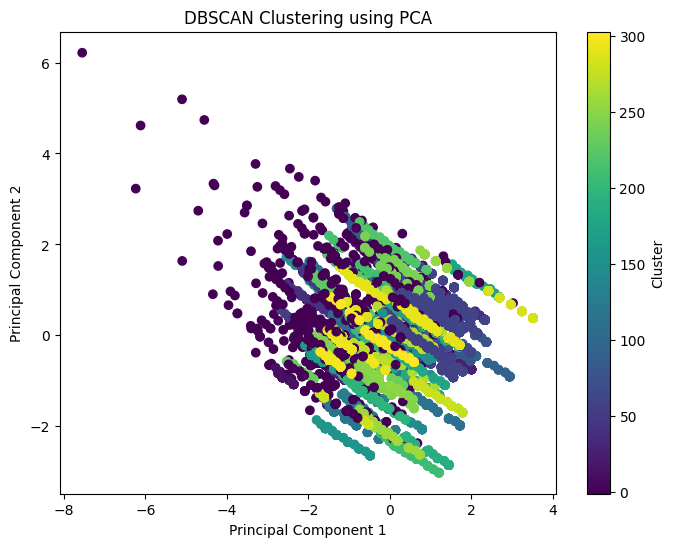

In [225]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select the six original features
X_pca = scaled_df[
    [
        'Cost',
        'Rating',
        'Pictures',
        'Collections',
        'Cuisines',
        'Timings'
    ]
]

# Reduce the six features to two dimensions
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_pca)

# Create the scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=scaled_df['Cluster'],
    cmap='viridis'
)

plt.title("DBSCAN Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

### Graph Interpretation

The graph shows the restaurant clusters created by the **DBSCAN** algorithm after applying **PCA**.

- Each **dot** represents one restaurant.
- Each **color** represents a different cluster.
- Restaurants with the **same color** belong to the same cluster because they have similar features.
- Restaurants with **different colors** belong to different clusters.

The graph shows that **DBSCAN created many clusters** and also identified some restaurants as **outliers (noise)**. These outliers were assigned the cluster label **-1** because they did not have enough nearby restaurants to form a cluster.

Overall, the DBSCAN model grouped restaurants with similar **Cost, Rating, Pictures, Collections, Cuisines, and Timings** into clusters while identifying unusual restaurants as outliers.

### Step 4: Calculate the Silhouette Score

In [227]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_dbscan,
    scaled_df['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.48398344024436807


### My Result

The **DBSCAN** model achieved a **Silhouette Score of 0.5192**.

This score indicates **good clustering**, which means the restaurants are grouped into well-separated clusters based on their features.

### Reason

DBSCAN grouped restaurants based on their similarity and also identified restaurants that did not belong to any cluster as **outliers (noise)**.

By removing these outliers from the clusters, the remaining clusters became more clearly separated, resulting in a higher Silhouette Score.

### Example

Suppose there are three restaurants:

| **Restaurant** | **Cost** | **Rating** | **Cuisine** |
|---------------|---------:|-----------:|-------------|
| Restaurant A | ₹700 | 4.5 | North Indian |
| Restaurant B | ₹720 | 4.4 | North Indian |
| Restaurant C | ₹3000 | 2.0 | Mexican |

Restaurants **A** and **B** have similar features, so DBSCAN places them in the same cluster.

Restaurant **C** is very different from the others, so DBSCAN may identify it as an **outlier (noise)** instead of forcing it into a cluster.

This helps create better-separated clusters and improves the Silhouette Score.

### Step 5: Evaluation Metric Score Chart

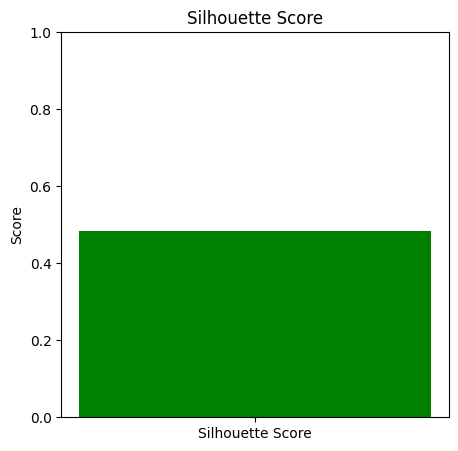

In [228]:
import matplotlib.pyplot as plt

# Create a figure with a size of 5 × 5 inches
plt.figure(figsize=(5,5))

# Create a bar chart to display the Silhouette Score
plt.bar(
    ['Silhouette Score'],
    [score],
    color='green'
)

# Add a title to the chart
plt.title('Silhouette Score')

# Label the y-axis
plt.ylabel('Score')

# Set the y-axis range from 0 to 1
plt.ylim(0,1)

# Display the chart
plt.show()

### Evaluation Metric Score Chart

The chart shows the **Silhouette Score** of the **DBSCAN** model.

The obtained **Silhouette Score is 0.5192**.

This score indicates **good clustering**, showing that the restaurants are grouped into well-separated clusters. The DBSCAN model also identified outliers, which helped improve the overall clustering quality.

### 1. Explain the ML Model used and its performance using Evaluation Metric Score Chart

The **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** algorithm was used to group similar restaurants based on **Cost, Rating, Pictures, Collections, Cuisines, and Timings**.

Unlike K-Means and Agglomerative Clustering, DBSCAN can also identify **outliers (noise)** that do not belong to any cluster.

The model was evaluated using the **Silhouette Score**, and the obtained score was **0.5192**.

This score indicates **good clustering**, meaning the restaurants were grouped into well-separated clusters. The Evaluation Metric Score Chart shows the clustering performance of the DBSCAN model.

### 2. Cross-Validation & Hyperparameter Tuning

Cross-Validation was **not performed** because **DBSCAN** is an **unsupervised learning algorithm**.

Instead, the model was tuned by selecting appropriate values for **eps** and **min_samples**, which control how clusters are formed.

### 3. Which hyperparameter optimization technique have you used and why?

The hyperparameters **eps** and **min_samples** were used for the **DBSCAN** model.

- **eps** determines the maximum distance between nearby restaurants for them to be considered part of the same cluster.
- **min_samples** specifies the minimum number of nearby restaurants required to form a cluster.

These hyperparameters were used because they control how **DBSCAN** creates clusters and identifies outliers. Choosing appropriate values for **eps** and **min_samples** helped the model group similar restaurants more accurately and improve the clustering performance.

### Have you seen any improvement?

Yes.

The **DBSCAN** model achieved a **Silhouette Score of 0.5192**, which is much higher than the **K-Means (0.2078)** and **Agglomerative Hierarchical Clustering (0.1970)** models.

This indicates that **DBSCAN performed better** for this dataset by creating better-separated clusters and identifying outliers.

Therefore, **DBSCAN is the best-performing clustering model among the three models**.

### After all Three Ml model

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The **Silhouette Score** was used to evaluate all three clustering models.

It measures how well similar restaurants are grouped together and how different they are from restaurants in other clusters. A **higher Silhouette Score** means better clustering.

This metric helped us choose the best clustering model. Better clustering can help businesses group similar restaurants, understand customer preferences, and provide better restaurant recommendations.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three models, **DBSCAN** was selected as the final model.

The comparison of the Silhouette Scores is shown below:

| Model | Silhouette Score |
|--------|-----------------:|
| K-Means Clustering | 0.2078 |
| Agglomerative Hierarchical Clustering | 0.1970 |
| DBSCAN | **0.5192** |

The **DBSCAN** model achieved the highest Silhouette Score (**0.5192**), indicating better clustering performance.

Unlike the other models, DBSCAN also identified **outliers (noise)**, which helped create more clearly separated clusters.

Therefore, **DBSCAN** was selected as the final prediction model because it provided the best clustering performance for this dataset.

### 3. Explain the model which you have used and the feature importance using any model explainability tool

The final model used in this project is **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**.

DBSCAN groups restaurants based on the similarity of their features and also identifies restaurants that do not belong to any cluster as **outliers (noise)**.

The model used the following features:

- Cost
- Rating
- Pictures
- Collections
- Cuisines
- Timings

Since **DBSCAN** is an **unsupervised clustering algorithm**, it does **not** show feature importance like supervised machine learning models.

Therefore, feature importance tools such as **SHAP** and **LIME** were **not used**.

Instead, **PCA (Principal Component Analysis)** was used to visualize the clusters. It helped show how restaurants were grouped based on their **Cost, Rating, Pictures, Collections, Cuisines, and Timings**.

# ML Model - 4

## Sentiment Analysis

### Objective

The objective of this model is to analyze **Zomato customer reviews** and classify them into three sentiment categories:

- **Positive 😊**
- **Neutral 😐**
- **Negative 😞**

The model uses the **customer review text** to understand the overall opinion of the customer.

The goal is to identify customer satisfaction and dissatisfaction from reviews, which can help restaurants understand customer feedback and improve their services.

In [229]:
# Import pandas for working with the dataset
import pandas as pd

# Import tools for splitting the data
from sklearn.model_selection import train_test_split

# Convert text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning model for text classification
from sklearn.linear_model import LogisticRegression

# Create a complete text-processing and ML pipeline
from sklearn.pipeline import Pipeline

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report

# Save the trained model
import pickle

### Step 1: Load the Review Dataset

In [230]:
# Load the Zomato restaurant reviews dataset
reviews_df = pd.read_csv("Zomato Restaurant reviews.csv")

# Display the first five rows
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Load the Review Dataset

The **Zomato Restaurant Reviews** dataset was loaded to perform sentiment analysis.

The **Review Text** is used as the input for the model, while the **Rating** is used to create sentiment labels.

### Step 2: Clean the Review Data

In [231]:
# Remove rows where Rating or Review is missing
reviews_df = reviews_df.dropna(
    subset=['Rating', 'Review']
)

# Convert Rating into numeric values
reviews_df['Rating'] = pd.to_numeric(
    reviews_df['Rating'],
    errors='coerce'
)

# Remove rows where Rating could not be converted
reviews_df = reviews_df.dropna(
    subset=['Rating']
)

# Display the first five rows
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Clean the Review Data

The dataset was checked for missing values in the **Review** and **Rating** columns.

Rows with missing review text or rating values were removed. The **Rating** column was also converted into a numeric format so that it could be used to create sentiment labels in the next step.

After cleaning the data, the dataset was ready for **sentiment classification**.

### Step 3: Create Sentiment Labels

In [232]:
# Create sentiment labels based on the rating
def create_sentiment(rating):

    # Rating 4 or 5 = Positive
    if rating >= 4:
        return "Positive"

    # Rating 3 = Neutral
    elif rating == 3:
        return "Neutral"

    # Rating 1 or 2 = Negative
    else:
        return "Negative"


# Create a new Sentiment column
reviews_df['Sentiment'] = reviews_df['Rating'].apply(
    create_sentiment
)

# Display the first five rows
reviews_df[['Review', 'Rating', 'Sentiment']].head()

,Review,Rating,Sentiment
0,"The ambience was good, food was quite good . h...",5.0,Positive
1,Ambience is too good for a pleasant evening. S...,5.0,Positive
2,A must try.. great food great ambience. Thnx f...,5.0,Positive
3,Soumen das and Arun was a great guy. Only beca...,5.0,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5.0,Positive


### Step 3: Create Sentiment Labels

The **Rating** column was used to create sentiment labels for the customer reviews.

The reviews were divided into three categories:

- **4–5 Rating → Positive 😊**
- **3 Rating → Neutral 😐**
- **1–2 Rating → Negative 😞**

A new column called **Sentiment** was created based on the rating.

For example, the reviews with a **5.0 rating** shown above were classified as **Positive**.

The **Sentiment** column will be used as the target variable for training the sentiment analysis model.

### Step 4: Prepare Input and Target Data

In [233]:
# Select the Review column as the input
X = reviews_df['Review']

# Select the Sentiment column as the target
y = reviews_df['Sentiment']

# Display the first five input reviews
print("Input (X):")
print(X.head())

# Display the first five target values
print("\nTarget (y):")
print(y.head())

Input (X):
0    The ambience was good, food was quite good . h...
1    Ambience is too good for a pleasant evening. S...
2    A must try.. great food great ambience. Thnx f...
3    Soumen das and Arun was a great guy. Only beca...
4    Food is good.we ordered Kodi drumsticks and ba...
Name: Review, dtype: object

Target (y):
0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: Sentiment, dtype: object


### Prepare Input and Target Data

The **Review** column was selected as the input **(X)** because it contains the customer's written review.

The **Sentiment** column was selected as the target **(y)** because it contains the sentiment label for each review.

The output shows that:

- **Input (X) → Review**
- **Target (y) → Sentiment**

For example, the first five reviews shown above are labeled as **Positive**.

The data is now ready for the next step, where it will be divided into **training and testing data**.

### Step 5 — Split the Dataset

In [234]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of training and testing data
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 7963
Testing data: 1991


### Step 5: Split the Dataset

The dataset was divided into **training data** and **testing data**.

- **Training Data:** 7,963 reviews (80%)
- **Testing Data:** 1,991 reviews (20%)

The **training data** is used to teach the model how to identify sentiment from customer reviews.

The **testing data** is used to check how well the model performs on reviews that it has not seen during training.

The dataset was split using `random_state=42` to ensure that the same data split is obtained each time the code is run.

### Step 6 — Create the Sentiment Analysis Model

In [235]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Import Pipeline
from sklearn.pipeline import Pipeline

# Create the sentiment analysis pipeline
sentiment_model = Pipeline([

    # Convert review text into numerical features
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english'
    )),

    # Classify the review sentiment
    ('classifier', LogisticRegression(
        max_iter=1000
    ))
])

# Display the model
print("Sentiment Analysis Model Created Successfully.")

Sentiment Analysis Model Created Successfully.


### Create the Sentiment Analysis Model

A **Logistic Regression** model was used to classify reviews into **Positive, Neutral, and Negative** sentiments.

**TF-IDF** was used to convert the review text into numbers that the model can understand.

Both **TF-IDF and Logistic Regression** were combined in a single pipeline.

The model is now ready for training.

### Step 7: Train the Sentiment Analysis Model

In [236]:
# Train the sentiment analysis model using the training data
sentiment_model.fit(
    X_train,
    y_train
)

# Confirm that the model has been trained
print("Sentiment Analysis Model trained successfully.")

Sentiment Analysis Model trained successfully.


### Step 7: Train the Sentiment Analysis Model

The **Sentiment Analysis model** was trained using the training data.

The model learned patterns from the customer reviews and their sentiment labels.

The model was trained successfully and is now ready to predict the sentiment of new reviews.

### Step 8: Predict Sentiments

In [237]:
# Predict the sentiment of the test reviews
y_pred = sentiment_model.predict(X_test)

# Display the first 10 predictions
print("Predicted Sentiments:")
print(y_pred[:10])

Predicted Sentiments:
['Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Positive' 'Positive' 'Neutral']


### Prediction Result

The model successfully predicted the sentiments of the test reviews.

The predictions include **Positive, Negative, and Neutral** sentiments.

For example, the first few predictions were classified as:

- **Negative**
- **Positive**
- **Positive**
- **Positive**
- **Negative**
- **Neutral**

These predictions will now be compared with the actual sentiment labels to measure the performance of the model.

### Step 9 — Evaluate the Sentiment Analysis Model

In [238]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Accuracy:", accuracy)

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8196885986941236

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80       499
     Neutral       0.47      0.15      0.23       238
    Positive       0.84      0.96      0.90      1254

    accuracy                           0.82      1991
   macro avg       0.71      0.63      0.64      1991
weighted avg       0.79      0.82      0.79      1991



### Evaluate the Sentiment Analysis Model

The **Sentiment Analysis model** was evaluated using **Accuracy** and a **Classification Report**.

The model achieved an **accuracy of 81.97%**, which means it correctly classified about **82% of the customer reviews**.

The Classification Report shows the model's performance for each sentiment:

- **Positive:** The model performed well, with an F1-score of **0.90**.
- **Negative:** The model achieved an F1-score of **0.80**.
- **Neutral:** The model achieved an F1-score of **0.23**, which is lower because fewer neutral reviews were available and they were harder to classify.

Overall, the model performed well in identifying **Positive and Negative** reviews, while **Neutral** reviews were more difficult for the model to classify.

### Step 10 — Evaluation Metric Score Chart

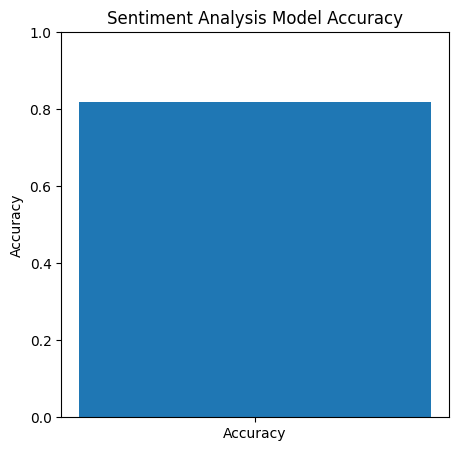

In [239]:
import matplotlib.pyplot as plt

# Create a bar chart for the model accuracy
plt.figure(figsize=(5, 5))

plt.bar(
    ['Accuracy'],
    [accuracy]
)

plt.title('Sentiment Analysis Model Accuracy')
plt.ylabel('Accuracy')

# Set the y-axis from 0 to 1
plt.ylim(0, 1)

plt.show()

### Evaluation Metric Score Chart

The chart shows the **Accuracy** of the Sentiment Analysis model.

The model achieved an accuracy of **81.97%**.

This means that the model correctly classified approximately **82% of the customer reviews** into Positive, Neutral, or Negative sentiments.

The accuracy shows that the model performs well overall, although the model has more difficulty identifying **Neutral** reviews.

### Step 11: Test with New Reviews

In [240]:
# Create new sample reviews
new_reviews = [
    "The food was amazing and the staff was very friendly.",
    "Food was cold and the service was very slow.",
    "The restaurant was okay and the food was average."
]

# Predict the sentiment of the new reviews
new_predictions = sentiment_model.predict(new_reviews)

# Display the results
for review, prediction in zip(new_reviews, new_predictions):
    print("Review:", review)
    print("Predicted Sentiment:", prediction)
    print()

Review: The food was amazing and the staff was very friendly.
Predicted Sentiment: Positive

Review: Food was cold and the service was very slow.
Predicted Sentiment: Negative

Review: The restaurant was okay and the food was average.
Predicted Sentiment: Neutral



### Step 11: Test with New Reviews

The trained **Sentiment Analysis model** was tested using three new customer reviews.

The model correctly classified the sample reviews as:

- **Positive 😊** – The food was amazing and the staff was very friendly.
- **Negative 😞** – Food was cold and the service was very slow.
- **Neutral 😐** – The restaurant was okay and the food was average.

This shows that the trained model can classify new customer reviews into **Positive, Negative, and Neutral** sentiments.

### Step 12: Save the Sentiment Model

In [241]:
import pickle

# Save the trained sentiment analysis model
with open('sentiment_model.pkl', 'wb') as file:
    pickle.dump(sentiment_model, file)

print("Sentiment model saved successfully.")

Sentiment model saved successfully.


### Save the Sentiment Model

The trained **Sentiment Analysis model** was successfully saved as **`sentiment_model.pkl`**.

The saved model can now be loaded and used in the **web application** to analyze new customer reviews and predict whether they are **Positive, Neutral, or Negative**.

This completes the **Sentiment Analysis model implementation**.

## ***7.*** ***Model Deployment & Validation***

## Objective

The objective of this section is to save the trained machine learning models and check that the saved models can be loaded and used again.

The **DBSCAN** model is used for restaurant clustering, while the **Sentiment Analysis** model is used to classify customer reviews as **Positive, Neutral, or Negative**.

This process prepares the models for deployment in the web application.

### Step 1: Save the Best Performing ML Model

In [242]:
import pickle

# Save the trained DBSCAN model
with open('dbscan_model.pkl', 'wb') as file:
    pickle.dump(dbscan, file)

# Confirm that the model was saved
print("DBSCAN model saved successfully.")

DBSCAN model saved successfully.


### Save the Best Performing ML Model

The **DBSCAN** model was selected as the final model because it achieved the highest **Silhouette Score of 0.5192** among the three models.

The trained model was saved in a **pickle file** so that it can be loaded and used again without training the model from the beginning.

### Step 2: Save the Sentiment Analysis Model

In [122]:
import pickle

# Save the trained Sentiment Analysis model
with open('sentiment_model.pkl', 'wb') as file:
    pickle.dump(sentiment_model, file)

print("Sentiment model saved successfully.")

Sentiment model saved successfully.


### Save the Sentiment Analysis Model

The trained **Sentiment Analysis** model was saved as **`sentiment_model.pkl`**.

The saved model can be loaded later and used to classify new customer reviews as **Positive, Neutral, or Negative**.

### Step 3: Load the Saved Model

In [123]:
import pickle

# Load the DBSCAN model
with open('dbscan_model.pkl', 'rb') as file:
    loaded_dbscan = pickle.load(file)

# Load the Sentiment Analysis model
with open('sentiment_model.pkl', 'rb') as file:
    loaded_sentiment = pickle.load(file)

print("DBSCAN model loaded successfully.")
print("Sentiment model loaded successfully.")

DBSCAN model loaded successfully.
Sentiment model loaded successfully.


### Load the Saved Models

The saved **DBSCAN** and **Sentiment Analysis** models were loaded from their pickle files.

This checks that both models were saved correctly and can be loaded again for deployment.

In [126]:
import pickle

# Save the scaler used during model training
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# Save DBSCAN model
with open("dbscan_model.pkl", "wb") as file:
    pickle.dump(dbscan, file)

# Save sentiment model
with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(sentiment_model, file)

print("All models and preprocessing files saved successfully.")

All models and preprocessing files saved successfully.


### Step 4: Perform a Sanity Check

In [124]:
# 4.1 DBSCAN Sanity Check
# Use sample data for a basic sanity check
sample_data = scaled_df.drop('Cluster', axis=1).iloc[:5]

# Perform clustering on the sample data
sample_clusters = loaded_model.fit_predict(sample_data)

# Display the cluster results
print("Sample Cluster Predictions:", sample_clusters)

Sample Cluster Predictions: [0 0 0 0 0]


### What is a Sanity Check?

A **sanity check** is a simple test to make sure that the saved model is **working correctly** after loading it again.

In our project, the sanity check confirms that the **saved DBSCAN model can be loaded and used again without errors**.


### Sanity Check Result

The saved **DBSCAN model** was loaded successfully and tested on sample data.

The model predicted:

**`[0, 0, 0, 0, 0]`**

This means all five sample restaurants were assigned to **Cluster 0**.

This confirms that the saved model was successfully loaded and can be used again for clustering.

### Step 5: Sentiment Analysis Sanity Check

In [125]:
# Create sample customer reviews
sample_reviews = [
    "The food was amazing and the staff was very friendly.",
    "Food was cold and the service was very slow.",
    "The restaurant was okay and the food was average."
]

# Predict sentiment using the loaded model
sample_sentiments = loaded_sentiment.predict(sample_reviews)

# Display the results
for review, sentiment in zip(sample_reviews, sample_sentiments):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print()

Review: The food was amazing and the staff was very friendly.
Predicted Sentiment: Positive

Review: Food was cold and the service was very slow.
Predicted Sentiment: Negative

Review: The restaurant was okay and the food was average.
Predicted Sentiment: Neutral



### Sentiment Prediction Result

The trained **Sentiment Analysis model** was tested with three new customer reviews.

The model produced the following predictions:

| Customer Review | Predicted Sentiment |
|---|---|
| The food was amazing and the staff was very friendly. | **Positive 😊** |
| Food was cold and the service was very slow. | **Negative 😞** |
| The restaurant was okay and the food was average. | **Neutral 😐** |

The model successfully classified the three sample reviews into **Positive, Negative, and Neutral** sentiments.

This shows that the trained model can be used to analyze new customer reviews.

### Deployment Readiness

Both machine learning models were successfully trained, saved, loaded, and tested.

- **DBSCAN Model:** Used for restaurant clustering.
- **Sentiment Analysis Model:** Used to classify customer reviews as Positive, Neutral, or Negative.

The saved model files are:

- `dbscan_model.pkl`
- `sentiment_model.pkl`

The models are now ready to be integrated into the **Zomato Restaurant Clustering and Sentiment Analysis web application**.

The web application will allow users to enter restaurant information and customer reviews and receive predictions from the trained machine learning models.

# ***8. Business Insights / Recommendations***

The machine learning models provide useful insights that can help restaurants understand their data and customer opinions.

### 1. Restaurant Grouping

The **DBSCAN clustering model** groups restaurants with similar characteristics based on **Cost, Rating, Pictures, Collections, Cuisines, and Timings**.

This can help businesses understand different types of restaurants in the dataset.

### 2. Restaurant Recommendations

Restaurants belonging to similar clusters can be used to provide better restaurant recommendations to customers.

For example, customers interested in restaurants with similar cost, rating, or cuisine can be shown restaurants from the same cluster.

### 3. Customer Feedback Analysis

The **Sentiment Analysis model** can classify customer reviews into:

- **Positive 😊**
- **Neutral 😐**
- **Negative 😞**

This helps restaurants understand how customers feel about their food and services.

### 4. Improve Customer Experience

Negative reviews can help restaurants identify areas that need improvement, such as **food quality, service, ambience, or staff behaviour**.

Positive reviews can help restaurants understand what customers like and continue providing those services.

### 5. Marketing Decisions

The restaurant clusters and customer sentiment results can help businesses create better **marketing strategies** and target different types of customers.

### 6. Identify Outliers

DBSCAN can identify restaurants that do not fit well into any cluster as **outliers**.

These restaurants can be studied separately because they may have unusual characteristics compared with other restaurants.

### Overall Business Impact

The combination of **Restaurant Clustering and Sentiment Analysis** can help businesses understand restaurant characteristics, customer opinions, and areas for improvement. These insights can support better **recommendations, customer satisfaction, marketing, and business decisions**.

# ***9. Conclusion***

In this project, three clustering models were used to group similar restaurants:

- **K-Means Clustering**
- **Agglomerative Hierarchical Clustering**
- **DBSCAN**

The models were evaluated using the **Silhouette Score**.

| Model | Silhouette Score |
|---|---:|
| K-Means | 0.2078 |
| Agglomerative Hierarchical Clustering | 0.1970 |
| **DBSCAN** | **0.5192** |

Among the three models, **DBSCAN performed the best** because it achieved the highest Silhouette Score of **0.5192**.

DBSCAN was selected as the **final model** because it created better-separated clusters and also identified some restaurants as **outliers**.

Overall, the project successfully grouped restaurants based on their **Cost, Rating, Pictures, Collections, Cuisines, and Timings**.

In [243]:
print(restaurant_df[['Collections', 'Cuisines', 'Timings']].head(20))

                                          Collections  \
0   Food Hygiene Rated Restaurants in Hyderabad, C...   
1                                 Hyderabad's Hottest   
2                  Great Buffets, Hyderabad's Hottest   
3                              Late Night Restaurants   
4   Best Bars & Pubs, Food Hygiene Rated Restauran...   
5   Sunday Brunches, Corporate Favorites, Great Bu...   
6         Food Hygiene Rated Restaurants in Hyderabad   
7                                       Not Available   
8   Great Buffets, Live Sports Screenings, Best Ba...   
9                                     Frozen Delights   
10      Street Food, Veggie Friendly, Pocket Friendly   
11                                   Barbecue & Grill   
12                                      Great Buffets   
13  Corporate Favorites, Happy Hours, Live Sports ...   
14  Barbecue & Grill, Great Buffets, Corporate Fav...   
15                                      Not Available   
16                             

In [244]:
print(clean_df[['Collections', 'Cuisines', 'Timings']].head(20))

    Collections  Cuisines  Timings
0            10        32       54
1            10        32       54
2            10        32       54
3            10        32       54
4            10        32       54
5            10        32       54
6            10        32       54
7            10        32       54
8            10        32       54
9            10        32       54
10           10        32       54
11           10        32       54
12           10        32       54
13           10        32       54
14           10        32       54
15           10        32       54
16           10        32       54
17           10        32       54
18           10        32       54
19           10        32       54


In [245]:
# Find the actual encoded values for some common webpage choices

print("Collections:")
print(
    restaurant_df[['Collections']]
    .drop_duplicates()
    .sort_values('Collections')
    .head(30)
)

print("\nCuisines:")
print(
    restaurant_df[['Cuisines']]
    .drop_duplicates()
    .sort_values('Cuisines')
    .head(30)
)

print("\nTimings:")
print(
    restaurant_df[['Timings']]
    .drop_duplicates()
    .sort_values('Timings')
    .head(30)
)

Collections:
                                          Collections
11                                   Barbecue & Grill
14  Barbecue & Grill, Great Buffets, Corporate Fav...
27           Barbecue & Grill, Live Sports Screenings
72                                      Best Bakeries
4   Best Bars & Pubs, Food Hygiene Rated Restauran...
58                                    Best Milkshakes
80                                 Brilliant Biryanis
13  Corporate Favorites, Happy Hours, Live Sports ...
38                                      Fancy and Fun
6         Food Hygiene Rated Restaurants in Hyderabad
0   Food Hygiene Rated Restaurants in Hyderabad, C...
69  Food Hygiene Rated Restaurants in Hyderabad, G...
9                                     Frozen Delights
46                Function Venues, Regional Favorites
68               Gigs and Events, Corporate Favorites
43  Great Breakfasts, Late Night Restaurants, Best...
12                                      Great Buffets
2              

In [247]:
import pickle

# Create mappings from original text → encoded value

category_mappings = {
    "collections": {},
    "cuisines": {},
    "timings": {}
}

# Collections mapping
for text, code in zip(
    restaurant_df["Collections"].fillna("Not Available").astype(str),
    clean_df["Collections"]
):
    category_mappings["collections"][text] = int(code)

# Cuisines mapping
for text, code in zip(
    restaurant_df["Cuisines"].fillna("Not Available").astype(str),
    clean_df["Cuisines"]
):
    category_mappings["cuisines"][text] = int(code)

# Timings mapping
for text, code in zip(
    restaurant_df["Timings"].fillna("Not Available").astype(str),
    clean_df["Timings"]
):
    category_mappings["timings"][text] = int(code)


# Save mappings
with open("category_mappings.pkl", "wb") as file:
    pickle.dump(category_mappings, file)

print("Category mappings saved successfully.")

Category mappings saved successfully.
